# Part A. Introduction

**Regression vs. classification**

In this project I treated the Spotify songs data set as a regression problem.
The Spotify songs data set was considered a regression issue for this work.
Dependent variable is track_popularity (0–100). Being bounded, I slightly adjusted the 0 and 100 values first and then applied a logit transform to generate a continuous response y that was suitable for linear regression.










# Part B.EDA
## a. Basic Information

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

import seaborn as sns

In [2]:
songs_url = ' https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv' 

df = pd.read_csv( songs_url ) 

###  Number of rows and columns

In [3]:
df.shape

(32833, 23)

### Variable names + data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

###  Number of missing values per variable

In [5]:
df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

###  Number of unique values per variable and duplicated values

In [6]:
df.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

In [7]:
df.duplicated().sum()

0

#### State whether any numeric columns should be treated as non-numeric for exploration purposes.

key – An integer ranging from 0 to 11, where each value corresponds to a musical note from C through B. fThe numbers represent distinct categories rather than ordered numeric values.

mode - musical mode as 0 = minor and 1 = major. This is a binary categorical variable, not a continuous numeric measurement.

Let's convert them:

In [8]:
df['key'] = df['key'].astype('category')
df['mode']= df['mode'].astype('category')

## b. Visualization
### Counts of categorical variables

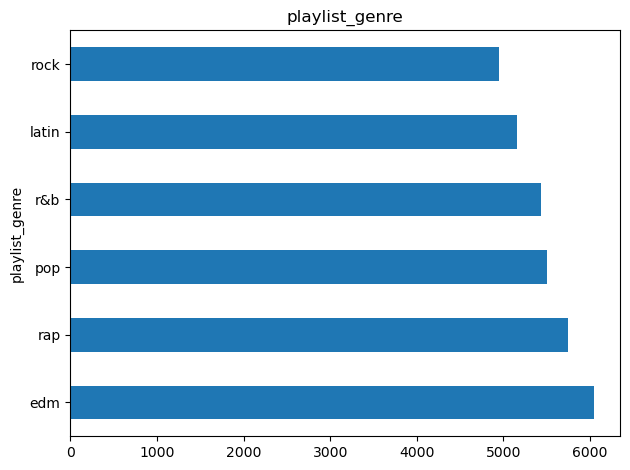

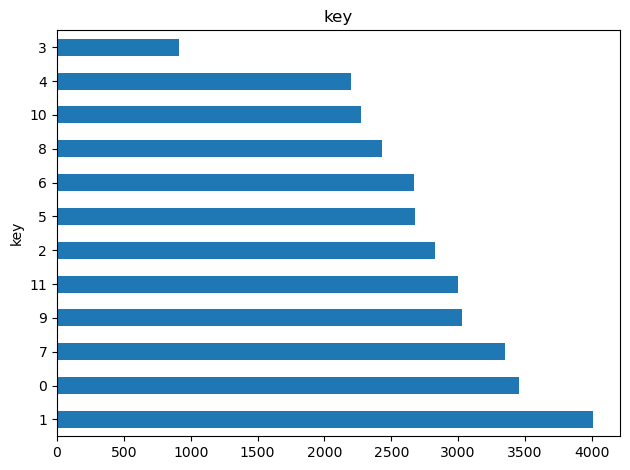

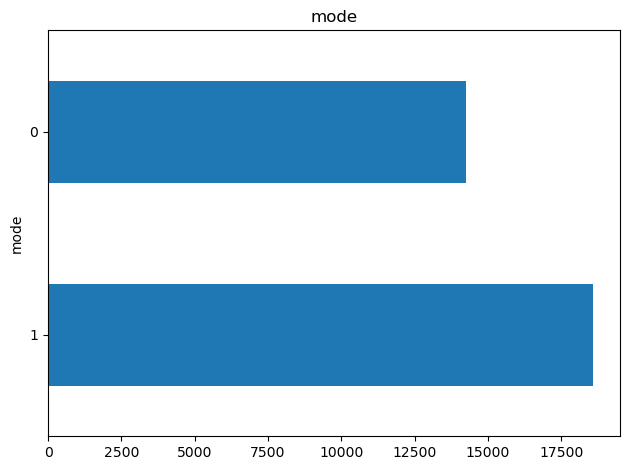

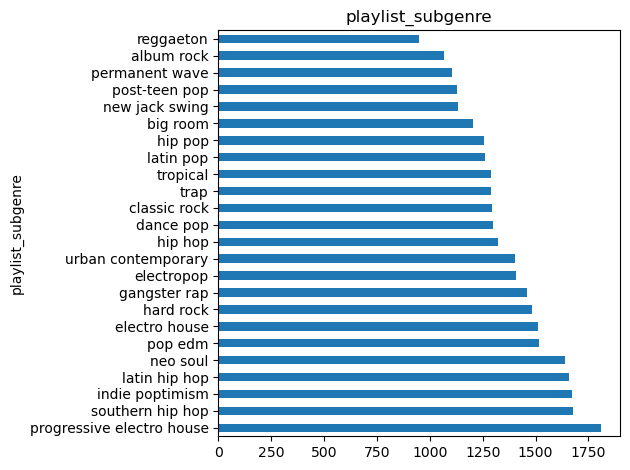

In [9]:
# List of categorical variables to visualize
categorical_cols = ['playlist_genre', 'key', 'mode','playlist_subgenre']

# Loop through the categorical cloumns and plot the bar chats
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='barh')
    plt.title(f'{col}')
    plt.tight_layout()
    plt.show()



In [53]:
df.groupby('playlist_genre')['track_popularity'].mean().sort_values()


playlist_genre
edm      34.833526
r&b      41.223532
rock     41.728338
rap      43.215454
latin    47.026576
pop      47.744870
Name: track_popularity, dtype: float64

Playlist Genre: The most common genre is EDM, followed by rap, pop, R&B, latin, and rock.

Key: Songs are distributed across all keys, with C major (key 0) being more frequent.

Mode: Most songs are in major mode (1).

Playlist Subgenre: There is a wide variety of subgenres. Progressive electro house, southern hip hop, and indie poptimism appear most often.

### Distributions of continuous variables

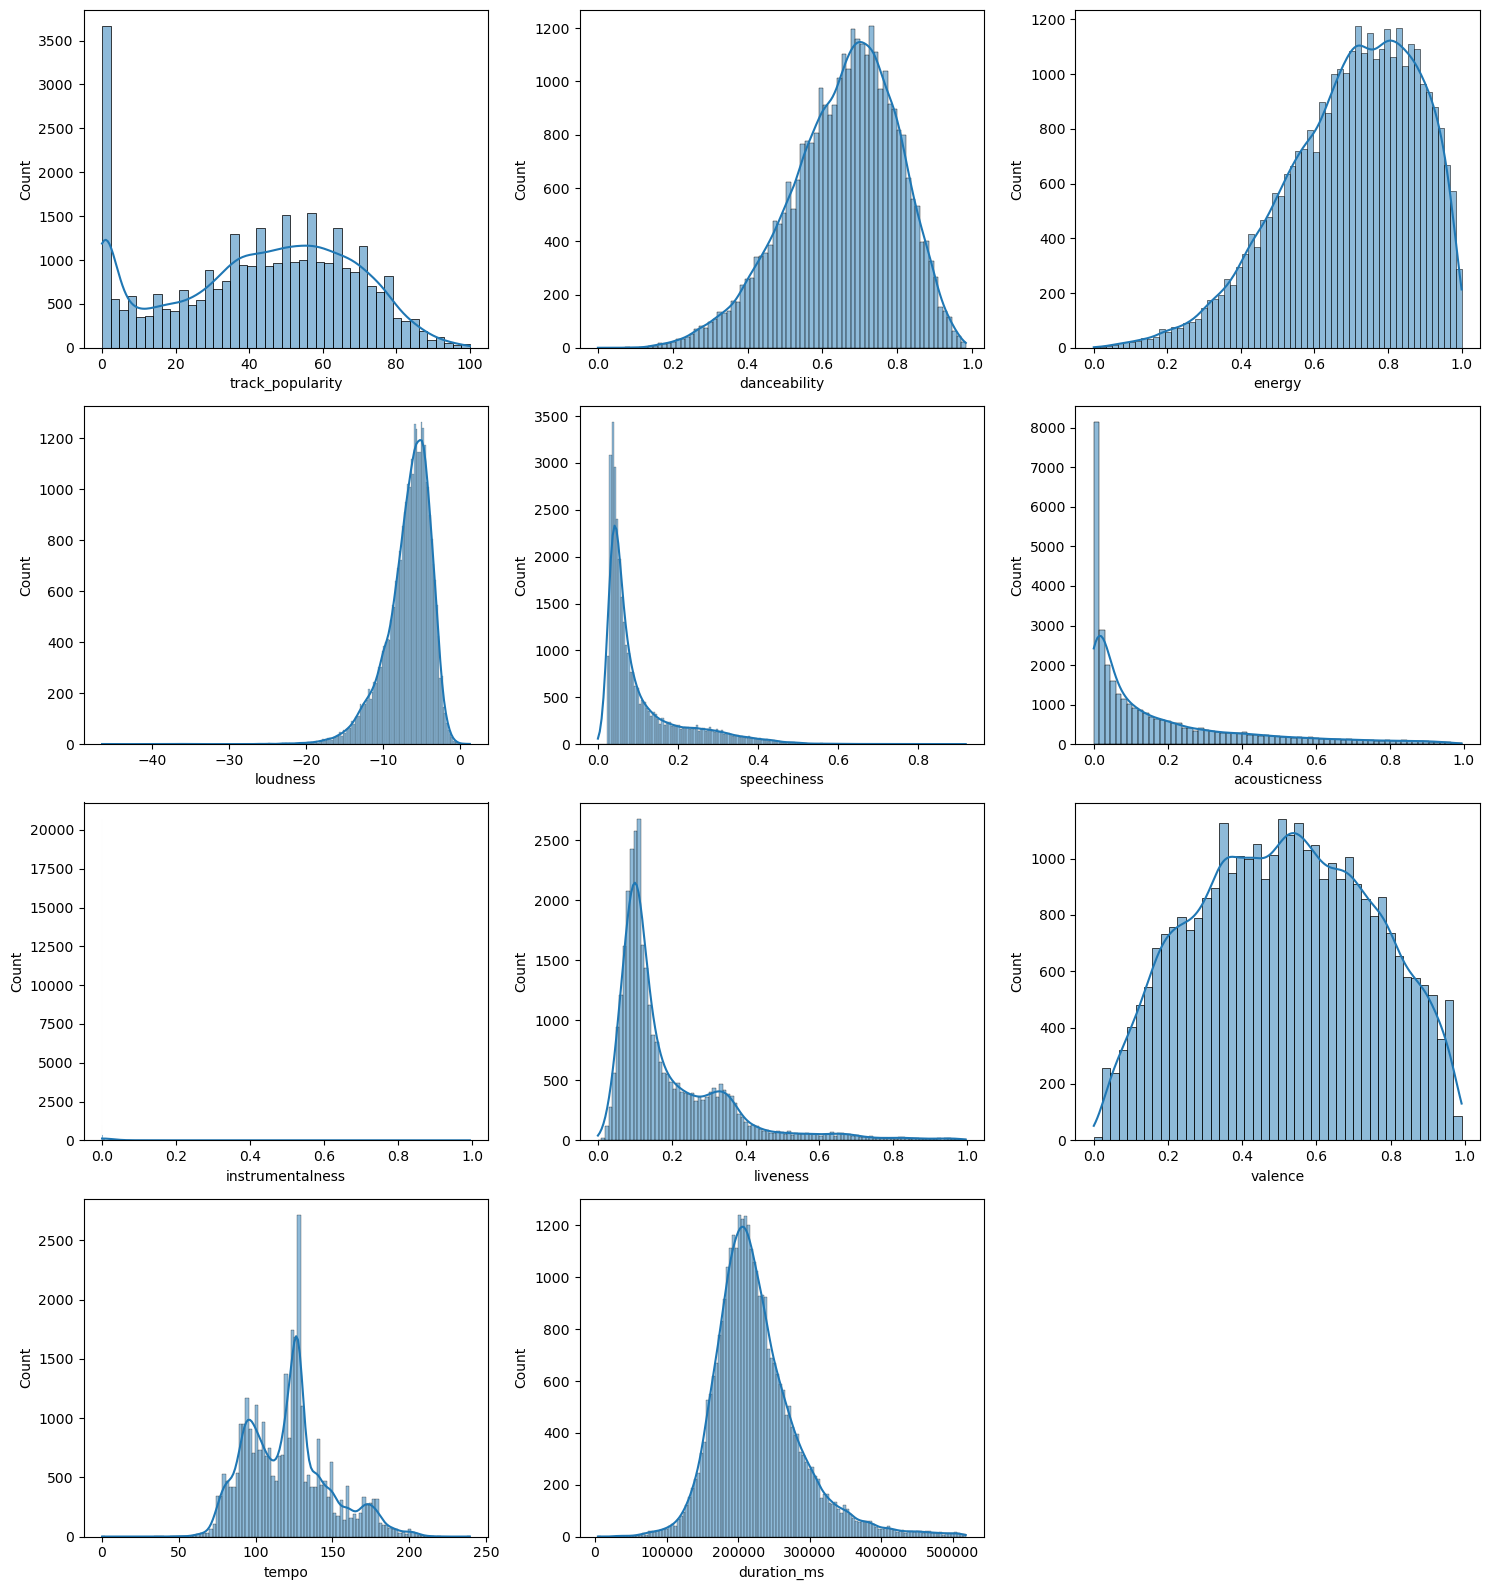

In [10]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Number of plots per row
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))

# Flatten axes array (in case n_rows=1 or more)
axes = axes.flatten()

# Loop through numeric columns and plot
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    

# Hide any empty subplots if total plots < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Track popularity: Bimodal; many songs have a score of zero, possibly indicating missing or undefined popularity data, while most other songs show moderate popularity levels.

Danceability & energy: Both are roughly bell-shaped; with most songs being moderately to highly danceable and energetic.

Loudness: Left-skewed; most songs a re loud (around -10 dB).

Speechiness & instrumentalness: Strong right-skew; most songs contain few spoken or instrumental parts.

Acousticness: Right-skewed; many songs are low in acoustic quality.

Liveness: Skewed toward low values; most songs are recorded in studio rather than live.

Valence: Fairly uniform; covers songs of all types.

Tempo: Multiple peaks; showing varied rhythmic styles.

Duration: Bell-shaped; most songs centered around 200,000–250,000 ms.

### Relationships between continuous variables


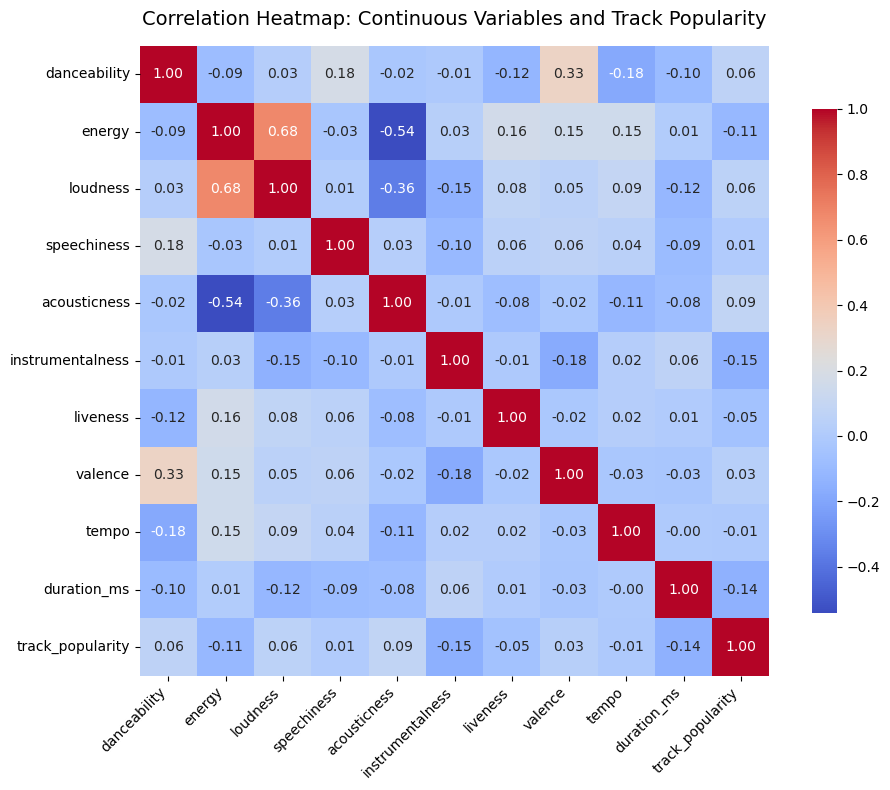

In [11]:
# Define continuous input variables
continuous_vars = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 
                  'valence', 'tempo', 'duration_ms']

target = 'track_popularity'

# Create a subset dataframe
subset_df = df[continuous_vars + [target]]

# Compute correlation matrix
corr = subset_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Continuous Variables and Track Popularity', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
df.groupby('playlist_genre')[['danceability','energy','valence','tempo']].mean().round(3)


,danceability,energy,valence,tempo
playlist_genre,,,,
edm,0.655,0.802,0.401,125.768
latin,0.713,0.708,0.606,118.622
pop,0.639,0.701,0.504,120.743
r&b,0.670,0.591,0.531,114.222
rap,0.718,0.651,0.505,120.655
rock,0.521,0.733,0.537,124.989


The results(-0.11,-0.15,-0.14) indicate that songs with higher instrumentalness, longer duration, and greater energy tend to be less popular. And results(0.09 and 0.06) indicate that songs with more natural sounds and louder tend to be more popular. But in general, correlations under +0.2 or -0.2 are considered very week.

### Summaries of continuous variables grouped by categorical variable

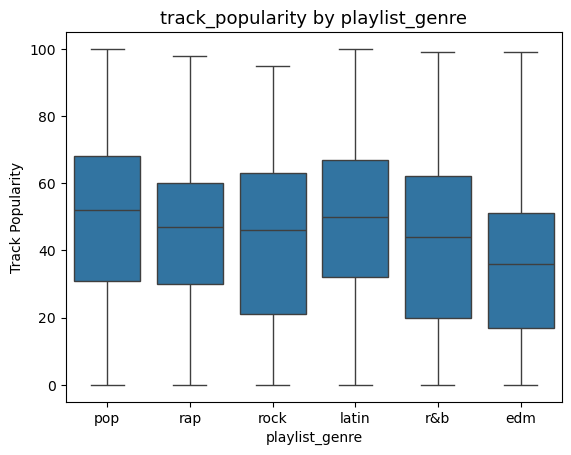

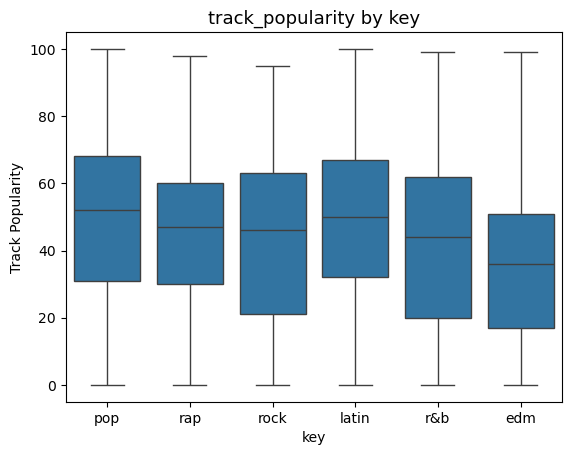

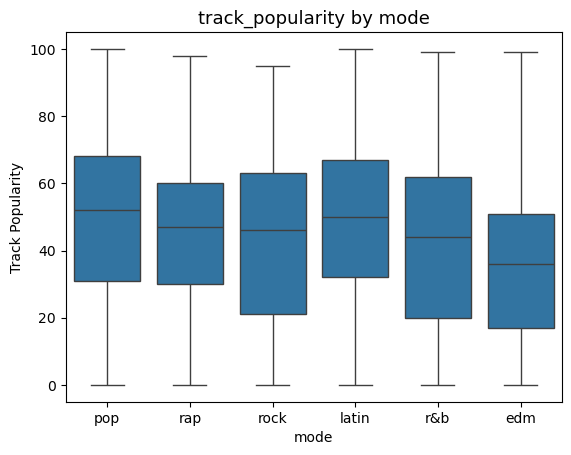

In [12]:
# Define categorical variables and target variable
categorical_variables = ['playlist_genre', 'key', 'mode']
target = 'track_popularity'

# Loop through categorical variables
for col in categorical_variables:
    # Boxplot
    sns.boxplot( data =df, x ='playlist_genre', y=target)
    plt.title(f'{target} by {col}',fontsize=13)
    plt.ylabel('Track Popularity')
    plt.xlabel(col)
    plt.show()
    

In [55]:
df.groupby('playlist_genre')['track_popularity'].describe()


,count,mean,std,min,25%,50%,75%,max
playlist_genre,,,,,,,,
edm,6043.0,34.833526,23.154235,0.0,17.0,36.0,51.0,99.0
latin,5155.0,47.026576,25.424557,0.0,32.0,50.0,67.0,100.0
pop,5507.0,47.744870,25.158331,0.0,31.0,52.0,68.0,100.0
r&b,5431.0,41.223532,25.894504,0.0,20.0,44.0,62.0,99.0
rap,5746.0,43.215454,23.302085,0.0,30.0,47.0,60.0,98.0
rock,4951.0,41.728338,24.825230,0.0,21.0,46.0,63.0,95.0


By Playlist Genre:

Boxplot Plot show the wide spread in both plots indicates that each genre includes songs with both high and low popularity;Pop and Latin songs have slightly higher median popularity.

By Key:

Boxplot Plot show that key has minimal influence on popularity.

By Mode:

Boxplot Plot show major mode songs show slightly higher median popularity.

### Regression-specific requirement: scatter plots of response vs continuous inputs


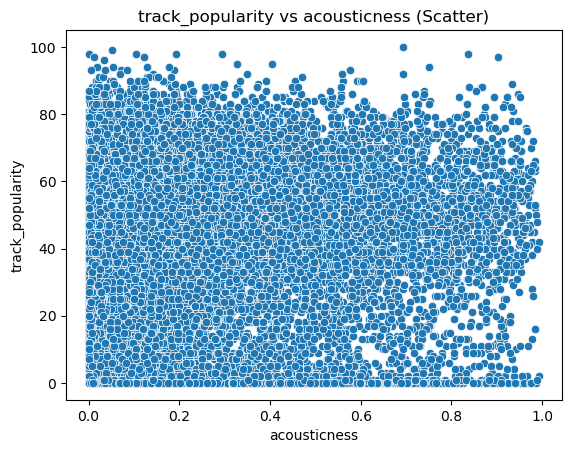

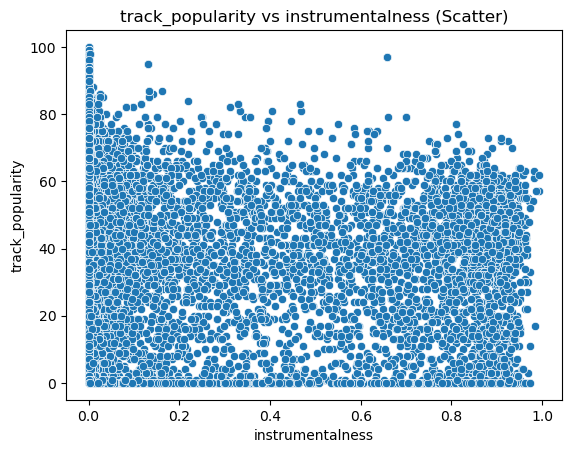

In [13]:
# Top 2 variables with strongest (positive & negative) correlation
top_vars = ['acousticness', 'instrumentalness']
target = 'track_popularity'

for col in top_vars:
    sns.scatterplot(data=df, x=col, y=target)
    plt.title(f'{target} vs {col} (Scatter)')
    plt.show()


Acousticness: There is no strong trend,but most popular songs cluster in the low to mid acousticness range.

Instrumentalness: A clear negative relationship is visible.

# Part C. Clustering
### Inputs and Method Choice

- Hierarchical Clustering 
* Cluster 1: high danceability, high energy, medium acousticness
* Cluster 2: high energy, mid danceability
* Cluster 3: high danceability, low instrumentalness
* Cluster 4: very high speechiness
* Cluster 5: very high acousticness & instrumentalness

These patterns are musically meaningful and easy to interpret.

- KMeans PCA & KMeans Original;Their cluster means are:
* less distinct
* less stable
* more overlapping
* harder to describe in real musical terms
* KMeans on original features required significantly longer runtime on this dataset


So Hierarchical Clustering  wins. Please see clustering_supporting_notebook for reference.

### Prepare Data for Clustering

In [14]:
# Continuous variables used for clustering
continuous_vars = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

from sklearn.preprocessing import StandardScaler

# Standardize continuous features
X_scaled = StandardScaler().fit_transform(df[continuous_vars])


Most features were moderately non-Gaussian,so standardization handles scale differences sufficiently.

### Choose Number of Clusters with Dendrogram


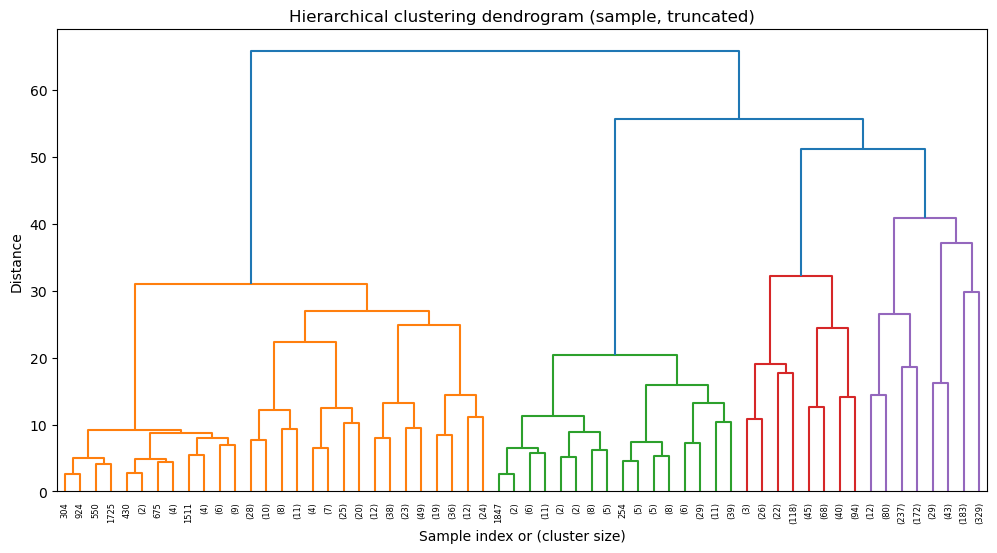

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sample_size = 2000
df_sample = df.sample(sample_size, random_state=121)
X_scaled_sample = StandardScaler().fit_transform(df_sample[continuous_vars])

Z = linkage(X_scaled_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical clustering dendrogram (sample, truncated)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()


I chose 5 clusters based on where there is a big jump in distance.

###  Fit Hierarchical Clustering on Full Data

In [16]:
# Linkage on full standardized data
Z_full = linkage(X_scaled, method='ward')

# Cut the tree to form 5 clusters
df['cluster_hc'] = fcluster(Z_full, 5, criterion='maxclust')

df['cluster_hc'].value_counts().sort_index()


cluster_hc
1     3002
2    15746
3     4962
4     3754
5     5369
Name: count, dtype: int64

### Summarize Continuous Inputs per Cluster


In [17]:
cluster_hc_summary = df.groupby('cluster_hc')[continuous_vars].mean()
cluster_hc_summary


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster_hc,,,,,,,,,,
1,0.654743,0.721867,-7.750615,0.079945,0.164155,0.735658,0.191250,0.406226,123.106993,231796.041639
2,0.626146,0.783459,-5.301089,0.072514,0.109441,0.017970,0.217810,0.518960,123.747789,217609.649117
3,0.704245,0.687047,-6.549159,0.290828,0.174857,0.005500,0.193896,0.561529,120.865258,220070.676139
4,0.608517,0.462760,-9.357795,0.067961,0.546520,0.020716,0.135318,0.426571,111.727831,229763.799680
5,0.725835,0.612412,-8.615557,0.081086,0.115740,0.034652,0.143450,0.555887,117.643999,248990.121810


### Compare Clusters to Categorical Variables

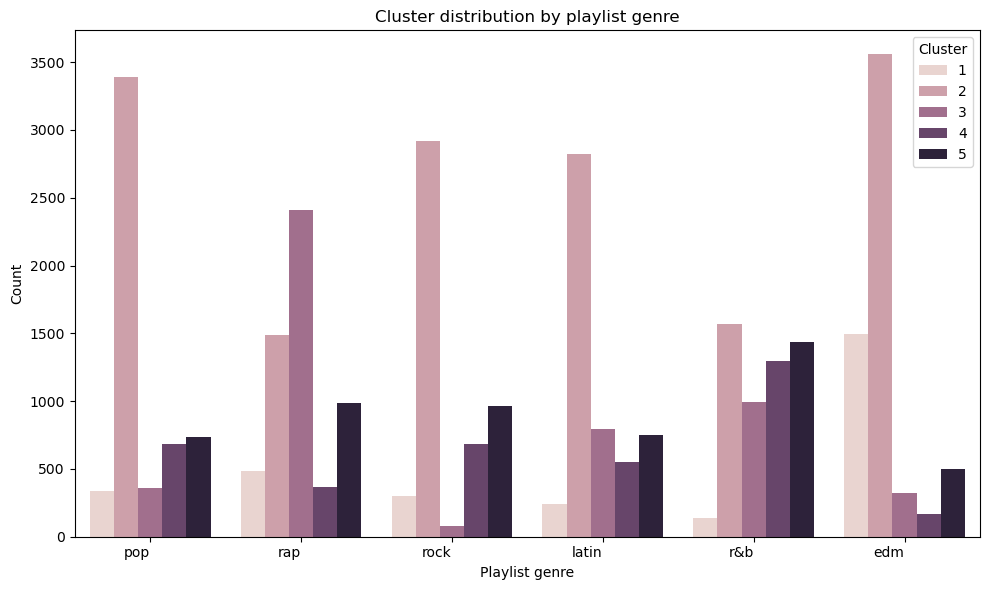

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='playlist_genre', hue='cluster_hc')
plt.xticks(rotation=90)
plt.title('Cluster distribution by playlist genre')
plt.xlabel('Playlist genre')
plt.xticks(rotation=0, ha='right')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


Cluster 2 (high-energy tracks) appears more frequently in genres such as EDM and pop, whereas Cluster 4 (quiet acoustic tracks) is more common in folk and singer-songwriter style playlists.

### PCA scatter colored by hierarchical clusters

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


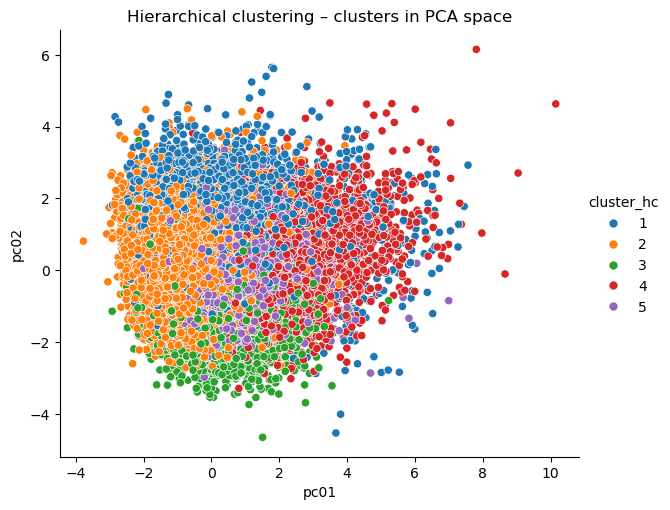

In [19]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

pca_spotify_df = pd.DataFrame(X_pca2, columns=['pc01', 'pc02'])
pca_spotify_df['cluster_hc'] = df['cluster_hc'].astype('category')

sns.relplot(data=pca_spotify_df,x='pc01', y='pc02',hue='cluster_hc',height=5, aspect=1.2)
plt.title('Hierarchical clustering – clusters in PCA space')
plt.show()


### Feature scatter (valence vs energy) by cluster

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


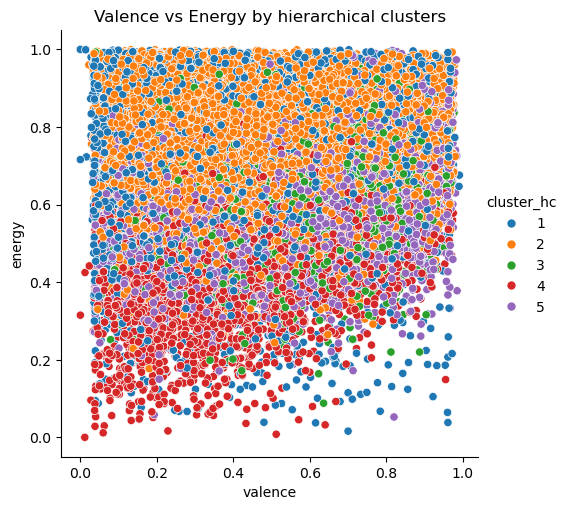

In [20]:
df_cluster_hc = df.copy()
df_cluster_hc['cluster_hc'] = df['cluster_hc'].astype('category')

sns.relplot(data=df_cluster_hc,x='valence', y='energy',hue='cluster_hc')
plt.title('Valence vs Energy by hierarchical clusters')
plt.show()


Although the clusters overlap (expected for real music data), some separation is visible in both PCA space and in valence–energy space, supporting the distinct cluster profiles observed in the summary table.

Clusters 1 and 2: Vaues mainly in the high-energy area, with varying levels of valence. Likly represent danceable tracks.

Cluster 3: Most values in the medium-energy level and mid- high valence region. Likly represent upbeat songs.

Cluster 4: Scattered across the all over the regions. Likly represent mixed characteristics songs.

Cluster 5: Concentrated in the low-energy range, representing calmer, slower, or softer songs.

# Part D. Models: Fitting and Interpretation

I am treating Spotify as a regression problem with a logit-transformed track_popularity. 



In [21]:
import statsmodels.formula.api as smf

df_mod = df.copy()

# shift 0 and 100
df_mod['track_pop_shift'] = np.where(df_mod.track_popularity == 100,
                                     df_mod.track_popularity - 0.1,
                                     df_mod.track_popularity)
df_mod['track_pop_shift'] = np.where(df_mod.track_popularity == 0,
                                     df_mod.track_popularity + 0.1,
                                     df_mod['track_pop_shift'])

# fraction + logit
df_mod['track_pop_frac'] = df_mod.track_pop_shift / 100
df_mod['y'] = np.log(df_mod.track_pop_frac / (1 - df_mod.track_pop_frac))

### Create 8 models: 

* 1.Intercept-only
* 2.Categorical inputs (playlist_genre, playlist_subgenre, key, mode)
* 3.Continuous audio features only
* 4.All inputs (categorical + continuous)
* 5.Continuous inputs + selected pairwise interactions
* 6.Categorical × continuous interactions
* 7.Polynomial term 
* 8.Cyclic term using sin(tempo)

And tempo has the largest scaling difference, so it needs to standardized. Other continuous features are fine because their ranges are reasonable and do not create major scaling issues.

In [22]:
continuous_vars = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
             'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

categorical_terms = 'C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode)'

df_mod['danceability_sq'] = df_mod['danceability']**2

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_mod['tempo_std'] =  scaler.fit_transform(df_mod[['tempo']])
df_mod['tempo_sin'] = np.sin(df_mod['tempo_std'])

In [24]:
formula_list = ['y ~ 1',
                f'y ~ {categorical_terms}',
                'y ~ ' + '+'.join(continuous_vars),
                f'y ~ {categorical_terms} + ' + '+'.join(continuous_vars),
                'y ~ ' + '+'.join(continuous_vars) + '+ danceability:energy + valence:energy + loudness:tempo',
                f'y ~ {categorical_terms} + '+' + '.join(continuous_vars) + '+ C(playlist_genre):danceability + C(key):energy',
                'y ~ ' + '+'.join(continuous_vars) + '+ danceability_sq',
                'y ~ ' + '+ '.join(continuous_vars) + '+ tempo_sin']

model_names = ['Intercept',
               'Categorical Only',
               'Continuous Only',
               'All Inputs',
               'Continuous + Interactions',
               'Categorical x Continuous',
               'Polynomial',
               'Cyclic']

In [25]:
# Fit All Models
models = []

for name, formula in zip(model_names, formula_list):
    mod = smf.ols(formula, data=df_mod).fit()
    models.append(mod)


### loop for fitting + coefficient plots (All 8 Models)

In [26]:
# Define a reusable coefficient plot function

def my_coefplot(mod, figsize_use=(10, 8)):
    fig, ax = plt.subplots(figsize=figsize_use)

    ax.errorbar(y=mod.params.index,
                x=mod.params.values,
                xerr=2 * mod.bse.values,   # 2 * standard error = approx 95% CI
                fmt='o',
                color='k',
                ecolor='k',
                elinewidth=1,
                ms=3)

    ax.axvline(x=0, linestyle='--', linewidth=1.5, color='grey')
    ax.set_xlabel('Coefficient value')
    ax.set_title('Coefficient estimates with 95% CI')
    plt.tight_layout()
    plt.show()


Fitting model: Intercept
Formula: y ~ 1


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.8274,0.012,-67.767,0.000,-0.851,-0.803


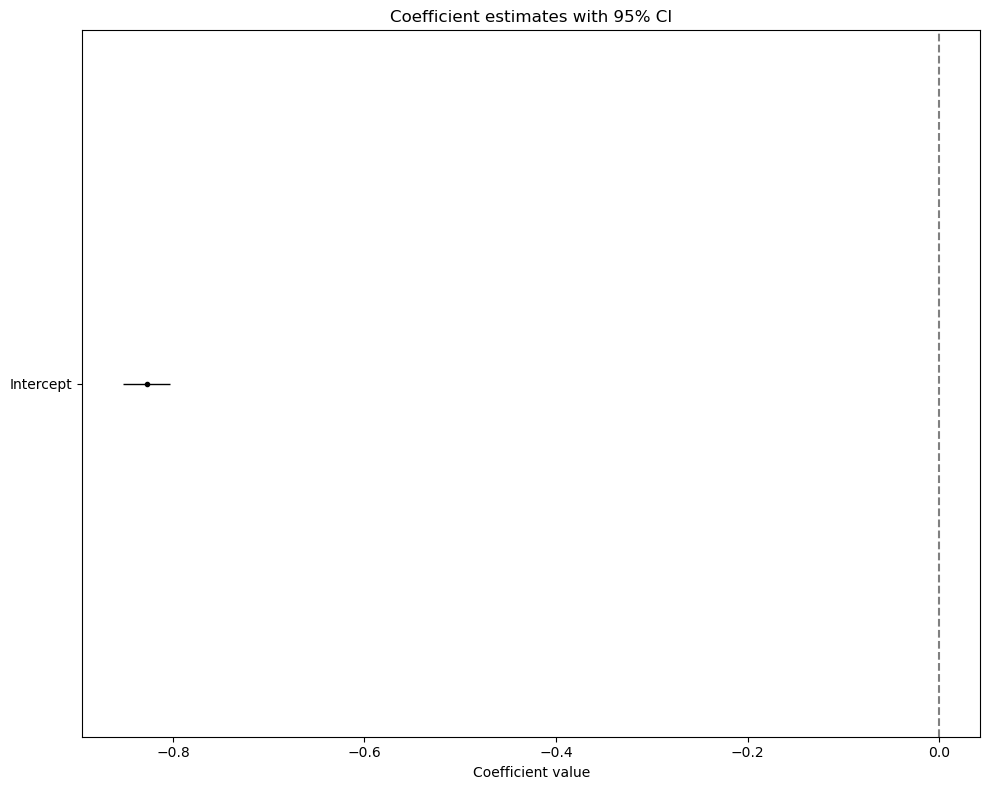

Fitting model: Categorical Only
Formula: y ~ C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.062e+10,1.11e+11,0.548,0.584,-1.56e+11,2.78e+11
C(playlist_genre)[T.latin],-1.381e+10,4.15e+10,-0.333,0.739,-9.52e+10,6.76e+10
C(playlist_genre)[T.pop],1.063e+10,2.8e+10,0.379,0.704,-4.43e+10,6.56e+10
C(playlist_genre)[T.r&b],-3.969e+10,1.47e+11,-0.271,0.787,-3.27e+11,2.48e+11
C(playlist_genre)[T.rap],1.241e+09,3.65e+11,0.003,0.997,-7.14e+11,7.17e+11
C(playlist_genre)[T.rock],-6.062e+10,1.11e+11,-0.548,0.584,-2.78e+11,1.56e+11
C(playlist_subgenre)[T.big room],-6.062e+10,1.11e+11,-0.548,0.584,-2.78e+11,1.56e+11
C(playlist_subgenre)[T.classic rock],0.2465,0.087,2.818,0.005,0.075,0.418
C(playlist_subgenre)[T.dance pop],-7.126e+10,1.13e+11,-0.629,0.529,-2.93e+11,1.51e+11
C(playlist_subgenre)[T.electro house],-6.062e+10,1.11e+11,-0.548,0.584,-2.78e+11,1.56e+11


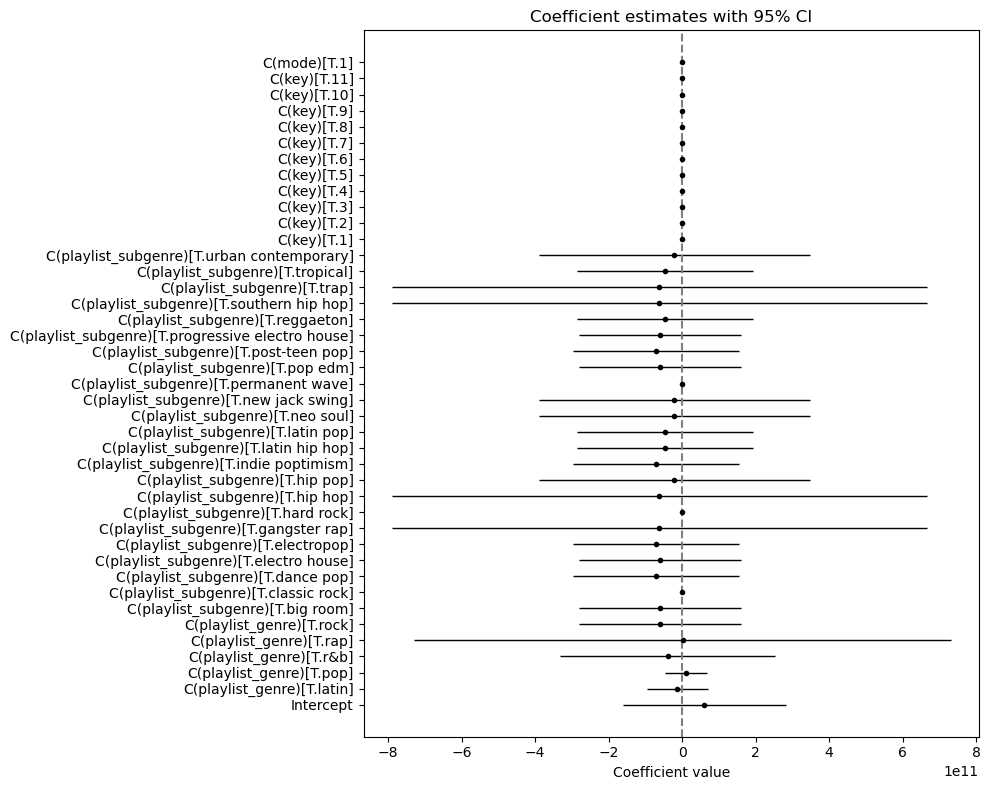

Fitting model: Continuous Only
Formula: y ~ danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.9639,0.148,13.308,0.000,1.675,2.253
danceability,0.4435,0.094,4.742,0.000,0.260,0.627
energy,-2.0943,0.107,-19.580,0.000,-2.304,-1.885
loudness,0.0943,0.006,16.458,0.000,0.083,0.106
speechiness,-0.6840,0.121,-5.657,0.000,-0.921,-0.447
acousticness,0.3055,0.065,4.675,0.000,0.177,0.434
instrumentalness,-0.8455,0.056,-15.024,0.000,-0.956,-0.735
liveness,-0.4199,0.079,-5.332,0.000,-0.574,-0.266
valence,0.0603,0.057,1.053,0.293,-0.052,0.172
tempo,0.0016,0.000,3.583,0.000,0.001,0.003


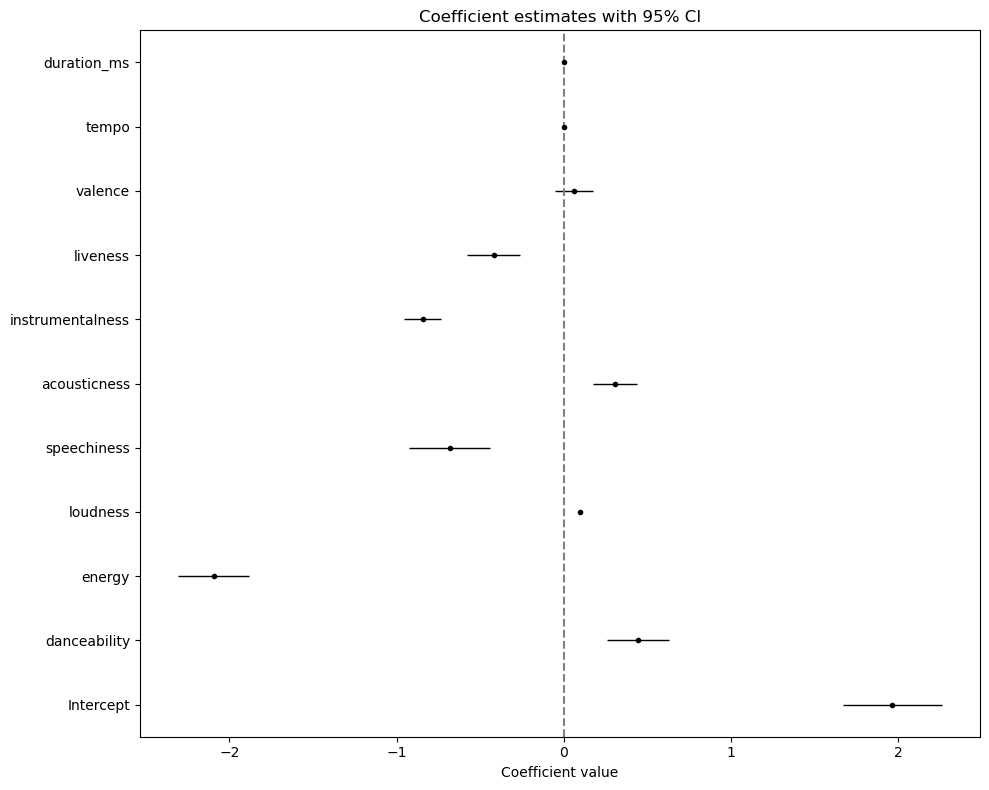

Fitting model: All Inputs
Formula: y ~ C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode) + danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.9550,0.137,6.949,0.000,0.686,1.224
C(playlist_genre)[T.latin],0.3741,0.029,12.751,0.000,0.317,0.432
C(playlist_genre)[T.pop],0.4935,0.026,18.701,0.000,0.442,0.545
C(playlist_genre)[T.r&b],0.0165,0.028,0.580,0.562,-0.039,0.072
C(playlist_genre)[T.rap],0.1580,0.029,5.378,0.000,0.100,0.216
C(playlist_genre)[T.rock],0.1941,0.064,3.042,0.002,0.069,0.319
C(playlist_subgenre)[T.big room],-0.1047,0.060,-1.745,0.081,-0.222,0.013
C(playlist_subgenre)[T.classic rock],0.2383,0.086,2.762,0.006,0.069,0.407
C(playlist_subgenre)[T.dance pop],0.5252,0.050,10.412,0.000,0.426,0.624
C(playlist_subgenre)[T.electro house],0.1680,0.055,3.041,0.002,0.060,0.276


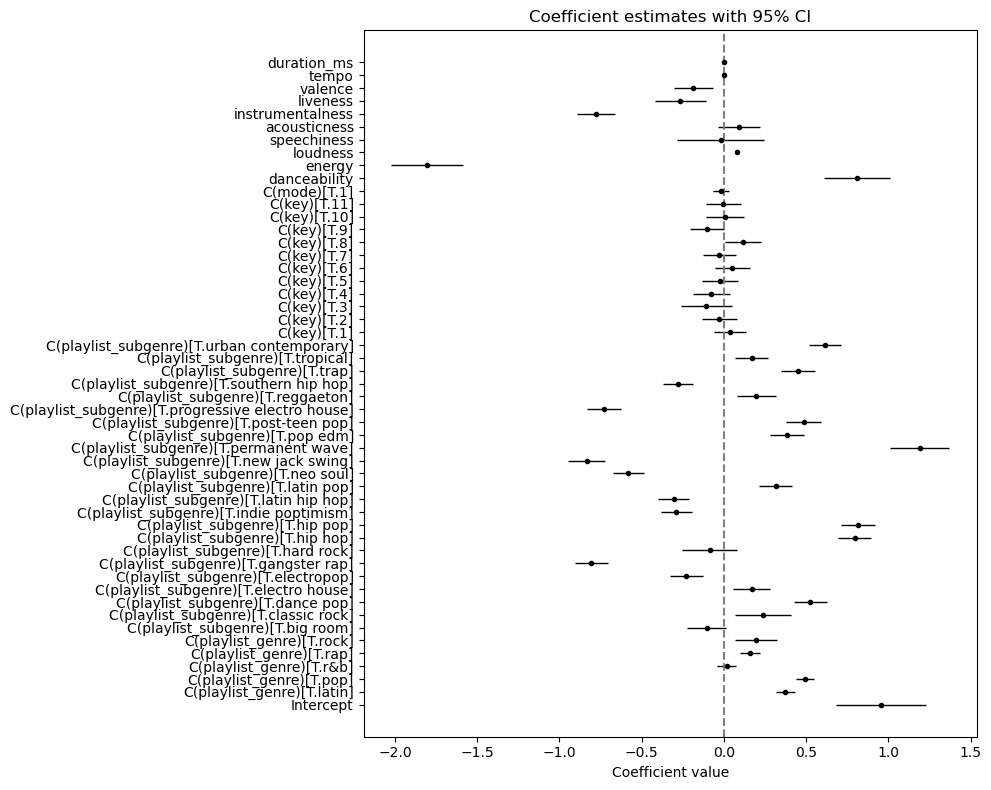

Fitting model: Continuous + Interactions
Formula: y ~ danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms+ danceability:energy + valence:energy + loudness:tempo


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.5739,0.265,5.929,0.000,1.054,2.094
danceability,1.8487,0.329,5.618,0.000,1.204,2.494
energy,-1.4874,0.300,-4.960,0.000,-2.075,-0.900
loudness,0.0996,0.018,5.618,0.000,0.065,0.134
speechiness,-0.7043,0.122,-5.784,0.000,-0.943,-0.466
acousticness,0.3216,0.067,4.832,0.000,0.191,0.452
instrumentalness,-0.8234,0.057,-14.571,0.000,-0.934,-0.713
liveness,-0.4179,0.079,-5.309,0.000,-0.572,-0.264
valence,-0.9947,0.223,-4.457,0.000,-1.432,-0.557
tempo,0.0012,0.001,1.152,0.249,-0.001,0.003


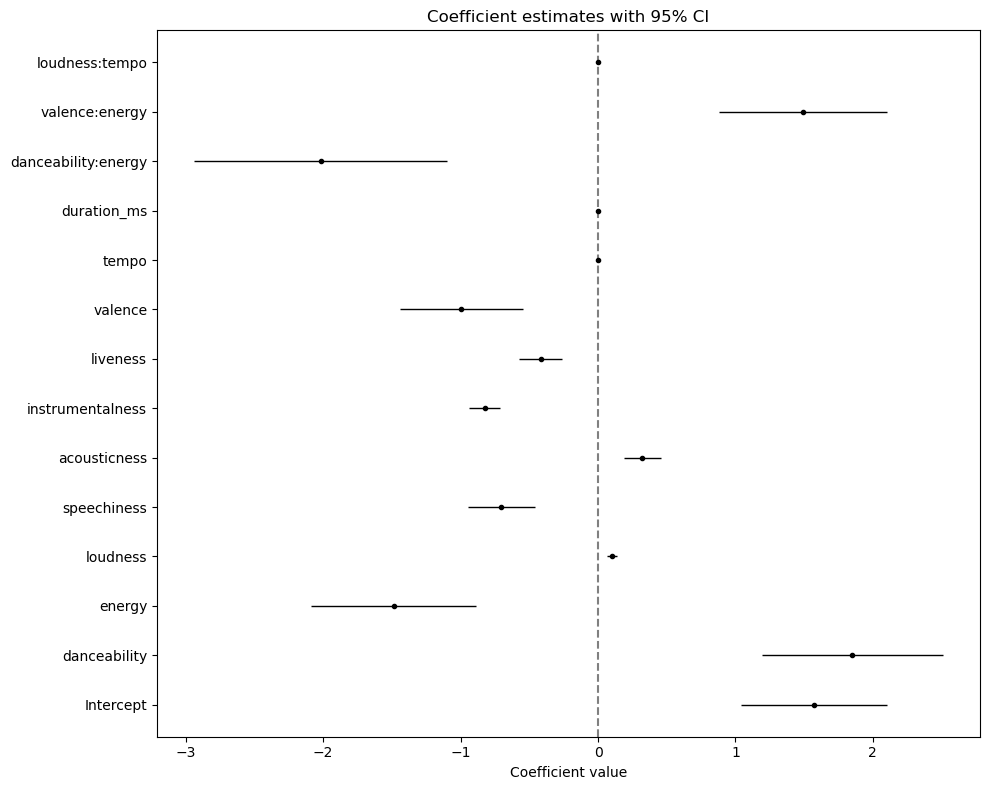

Fitting model: Categorical x Continuous
Formula: y ~ C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode) + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms+ C(playlist_genre):danceability + C(key):energy


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.0519,0.182,5.774,0.000,0.695,1.409
C(playlist_genre)[T.latin],0.5584,0.150,3.710,0.000,0.263,0.853
C(playlist_genre)[T.pop],0.1498,0.120,1.245,0.213,-0.086,0.386
C(playlist_genre)[T.r&b],0.3497,0.123,2.851,0.004,0.109,0.590
C(playlist_genre)[T.rap],-0.1452,0.124,-1.173,0.241,-0.388,0.097
C(playlist_genre)[T.rock],0.2640,0.139,1.903,0.057,-0.008,0.536
C(playlist_subgenre)[T.big room],-0.0713,0.101,-0.703,0.482,-0.270,0.128
C(playlist_subgenre)[T.classic rock],0.2434,0.086,2.820,0.005,0.074,0.413
C(playlist_subgenre)[T.dance pop],0.4290,0.060,7.171,0.000,0.312,0.546
C(playlist_subgenre)[T.electro house],0.2104,0.112,1.875,0.061,-0.010,0.430


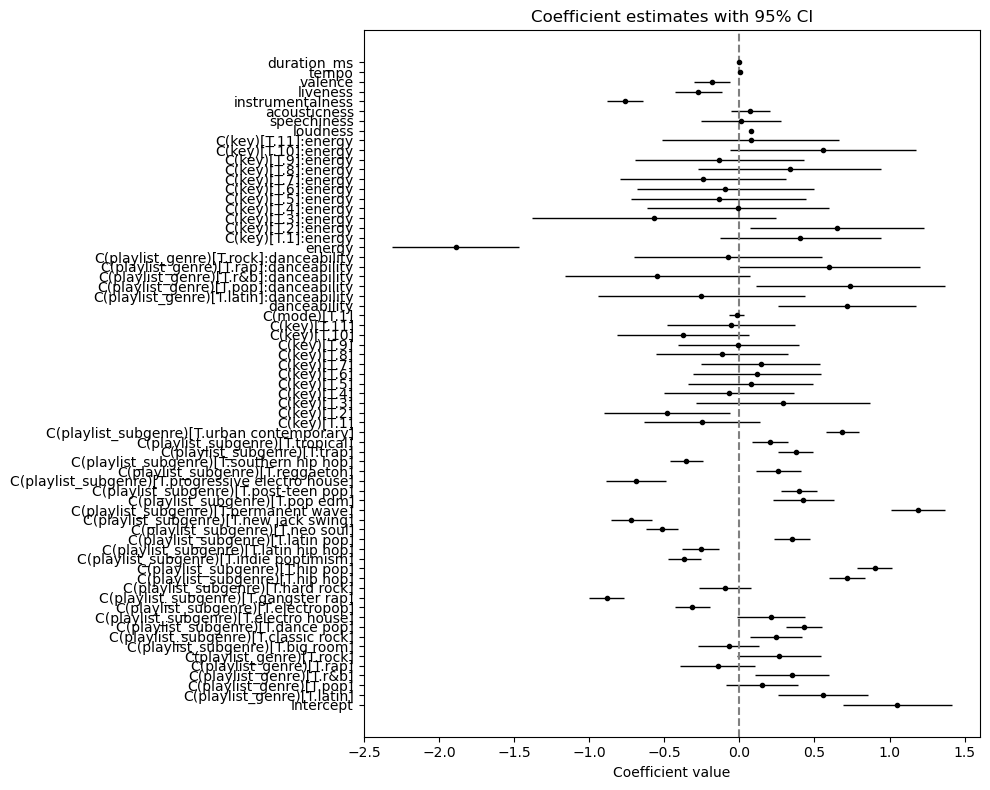

Fitting model: Polynomial
Formula: y ~ danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms+ danceability_sq


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.5899,0.211,12.262,0.000,2.176,3.004
danceability,-1.7563,0.539,-3.257,0.001,-2.813,-0.699
energy,-2.0498,0.107,-19.073,0.000,-2.260,-1.839
loudness,0.0941,0.006,16.429,0.000,0.083,0.105
speechiness,-0.7360,0.122,-6.056,0.000,-0.974,-0.498
acousticness,0.3212,0.065,4.908,0.000,0.193,0.449
instrumentalness,-0.8487,0.056,-15.082,0.000,-0.959,-0.738
liveness,-0.4213,0.079,-5.352,0.000,-0.576,-0.267
valence,0.0546,0.057,0.955,0.340,-0.058,0.167
tempo,0.0016,0.000,3.503,0.000,0.001,0.002


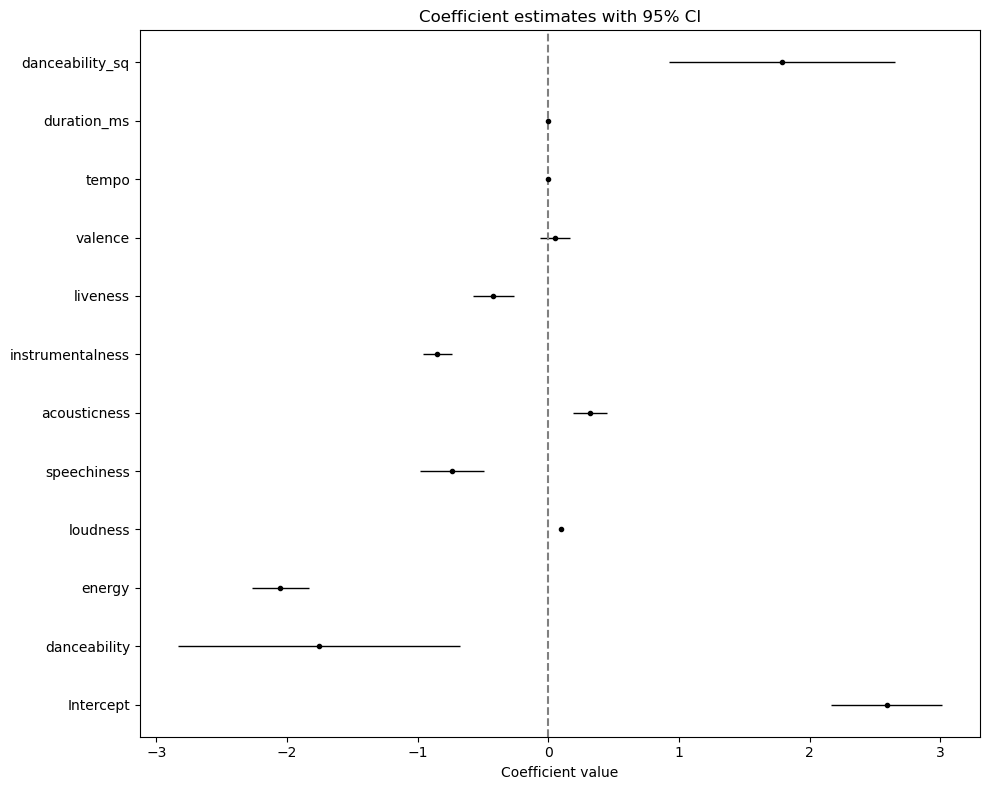

Fitting model: Cyclic
Formula: y ~ danceability+ energy+ loudness+ speechiness+ acousticness+ instrumentalness+ liveness+ valence+ tempo+ duration_ms+ tempo_sin


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.4623,0.204,7.158,0.000,1.062,1.863
danceability,0.4733,0.094,5.041,0.000,0.289,0.657
energy,-2.0677,0.107,-19.288,0.000,-2.278,-1.858
loudness,0.0936,0.006,16.336,0.000,0.082,0.105
speechiness,-0.7425,0.122,-6.085,0.000,-0.982,-0.503
acousticness,0.3045,0.065,4.660,0.000,0.176,0.433
instrumentalness,-0.8348,0.056,-14.815,0.000,-0.945,-0.724
liveness,-0.4094,0.079,-5.197,0.000,-0.564,-0.255
valence,0.0332,0.058,0.575,0.565,-0.080,0.146
tempo,0.0055,0.001,4.659,0.000,0.003,0.008


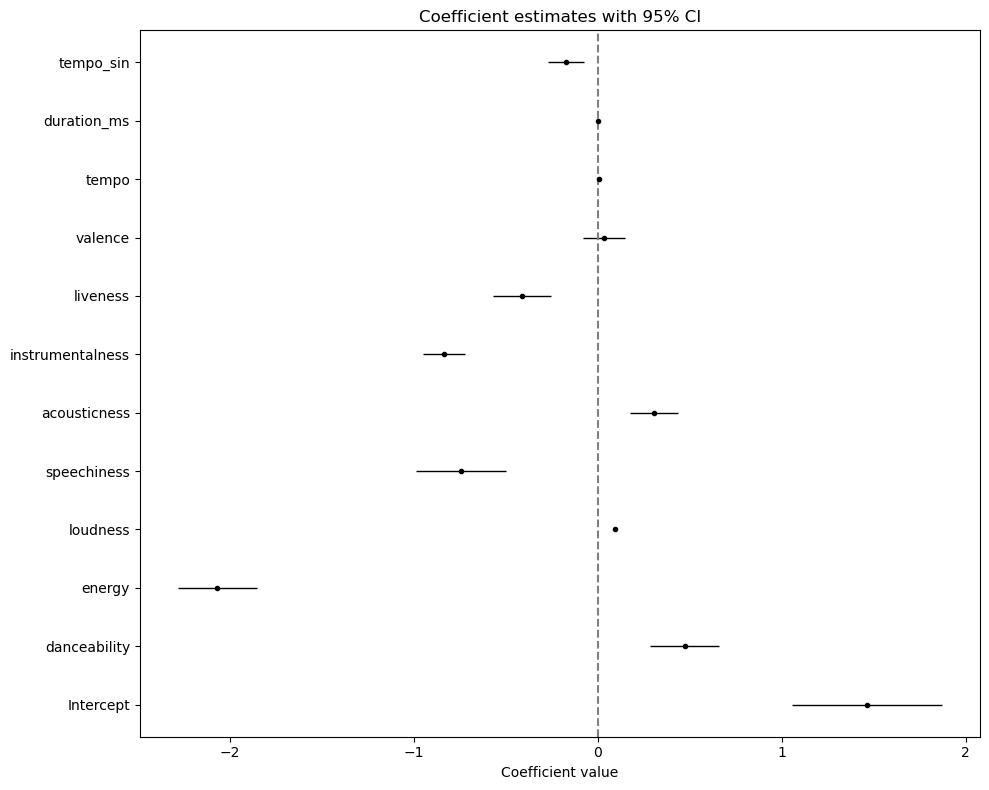

In [27]:
models = []

for name, formula in zip(model_names, formula_list):
    print("="*80)
    print(f"Fitting model: {name}")
    print("Formula:", formula)
    print("="*80)

    mod = smf.ols(formula, data=df_mod).fit()
    models.append(mod)

    # show coefficient table (shorter than full summary)
    display(mod.summary().tables[1])

    # coefficient plot (your custom function)
    my_coefplot(mod)

- 1.Intercept-Only Model:
* Only the intercept is estimated.
* No predictive power.
* Serves only as a baseline.
* R^2 ≈ 0 → worst model.

- 2. Categorical-Only Model:
* Several dummy variables for each categorical variable.
* Extremely broad confidence bands.
* Numerous coefficients are exceptionally unstable.
* Hard to interpret.
* Not a strong predictive model.

- 3. Continuous-Only Model:
* Continuous audio features only.
* Numerous coefficients are relevant (optimality, speechiness, variance of energy, variance of speechiness, variance of liveness, etc.).
* CI plots are narrow -> estimates are reliable.
* Somewhat understandable but not optimal.

- 4. All Inputs (Categorical + Continuous):
* Extensive set of coefficients.
* Comprehensive categorical levels and continuous parameters integrated.
* CI plots indicate:Some coefficients are unstable.
* R^2 enhances significantly, RMSE lessens.
* mproved forecasting, but deciphering is challenging with the number of variables.
* A decent model statistically but not the leanest.
  
- 5. Continuous + Interactions:
* Pairwise interactions among continuous variables.
* Certain cross-product regressors substantial and statistically significant (e.g., valence × energy, danceability × energy).
* CI plots reveal more defined organization.
* Clear elucidation of inter-feature correlations.
* Performance not as high as categorical×continuous model.

- 6. Categorical × Continuous:
* Interactions between categorical variables and continuous features.
* Many terms significant.
* CI lines are tight and stable.
* Best R^2 among all models I reported. 
* Certain genres significantly raise or lower y.Energy, danceability, loudness effects vary by genre/subgenre.
* The model behaves stable and predictable. Best so far. 


- 7. Polynomial Model:
* Certain polynomial constituents matter.
* Moderate but stable coefficients.
* R^2 and RMSE not as good as categorical×continuous.

- 8. Cyclic Model (tempo_sin):
* Includes a cyclic term for tempo to model repeating/periodic behaviour.
* Few large cyclic terms.
* Predictive performance no better than best model.
* Useful for capturing periodic structure, but not a top model.



Best Overall Model: Categorical × Continuous Interactions


### Coefficient Significance & Performance Summary Table (All 8 models)

In [28]:
comparison_rows = []

for name, mod in zip(model_names, models):

    # basic metrics
    r2 = mod.rsquared
    rmse = np.sqrt(np.mean((mod.fittedvalues - df_mod['y'])**2))
    num_params = len(mod.params)

    # significance
    sig_mask = mod.pvalues < 0.05
    num_significant = sig_mask.sum()

    # list of significant coefficient names
    sig_coeff_names = mod.params[sig_mask].index.tolist()

    # coefficient values for significant ones
    sig_coeff_values = mod.params[sig_mask]

    # direction: positive/negative
    sig_direction = [f"{coef_name}: {'+' if coef_value > 0 else '-'}"
        for coef_name, coef_value in sig_coeff_values.items()]

    # find the TWO significant coefficients with the largest magnitude
    if num_significant >= 2:
        top2 = sig_coeff_values.abs().sort_values(ascending=False).head(2)
        top2_feats = [f"{idx}: {mod.params[idx]:.4f}" for idx in top2.index]
    else:
        top2_feats = ['Not enough significant coefficients']

    # append row to list
    comparison_rows.append({
        'Model': name,
        'R_squared': r2,
        'RMSE': rmse,
        'Num_params': num_params,
        'Num_significant': num_significant,
        'Significant_coeffs': sig_coeff_names,
        'Significant_direction': sig_direction,
        'Top2_largest_coeffs': top2_feats})

# create table
comparison_df = pd.DataFrame(comparison_rows)

# make index start at 1
comparison_df.index = range(1, len(comparison_df) + 1)

comparison_df

,Model,R_squared,RMSE,Num_params,Num_significant,Significant_coeffs,Significant_direction,Top2_largest_coeffs
1,Intercept,2.842171e-14,2.212309,1,1,[Intercept],[Intercept: -],[Not enough significant coefficients]
2,Categorical Only,8.773317e-02,2.113035,41,4,"[C(playlist_subgenre)[T.classic rock], C(playl...","[C(playlist_subgenre)[T.classic rock]: +, C(pl...",[C(playlist_subgenre)[T.permanent wave]: 1.238...
3,Continuous Only,5.645113e-02,2.148958,11,10,"[Intercept, danceability, energy, loudness, sp...","[Intercept: +, danceability: +, energy: -, lou...","[energy: -2.0943, Intercept: 1.9639]"
4,All Inputs,1.167919e-01,2.079109,51,34,"[Intercept, C(playlist_genre)[T.latin], C(play...","[Intercept: +, C(playlist_genre)[T.latin]: +, ...","[energy: -1.8041, C(playlist_subgenre)[T.perma..."
5,Continuous + Interactions,5.737072e-02,2.147911,14,12,"[Intercept, danceability, energy, loudness, sp...","[Intercept: +, danceability: +, energy: -, lou...","[danceability:energy: -2.0187, danceability: 1..."
6,Categorical x Continuous,1.181376e-01,2.077524,67,34,"[Intercept, C(playlist_genre)[T.latin], C(play...","[Intercept: +, C(playlist_genre)[T.latin]: +, ...","[energy: -1.8913, C(playlist_subgenre)[T.perma..."
7,Polynomial,5.694408e-02,2.148397,12,11,"[Intercept, danceability, energy, loudness, sp...","[Intercept: +, danceability: -, energy: -, lou...","[Intercept: 2.5899, energy: -2.0498]"
8,Cyclic,5.681330e-02,2.148546,12,11,"[Intercept, danceability, energy, loudness, sp...","[Intercept: +, danceability: +, energy: -, lou...","[energy: -2.0677, Intercept: 1.4623]"





### Dobule check and choose the Best Model (R² vs RMSE + Compare to Intercept)

In [29]:
best_by_rmse = comparison_df.sort_values('RMSE').iloc[0]
best_by_r2 = comparison_df.sort_values('R_squared', ascending=False).iloc[0]

best_by_rmse, best_by_r2


(Model                                             Categorical x Continuous
 R_squared                                                         0.118138
 RMSE                                                              2.077524
 Num_params                                                              67
 Num_significant                                                         34
 Significant_coeffs       [Intercept, C(playlist_genre)[T.latin], C(play...
 Significant_direction    [Intercept: +, C(playlist_genre)[T.latin]: +, ...
 Top2_largest_coeffs      [energy: -1.8913, C(playlist_subgenre)[T.perma...
 Name: 6, dtype: object,
 Model                                             Categorical x Continuous
 R_squared                                                         0.118138
 RMSE                                                              2.077524
 Num_params                                                              67
 Num_significant                                               

The lowest RMSE (2.0775) and the highest R^2 (0.1181) both occur for the Categorical × Continuous model.So the best model is Categorical x Continuous. And the two strongest statistically significant coefficients are Energy and Playlist Subgenre: Permanent Wave as shown in the table.

### predicted vs observed plot for just the best model

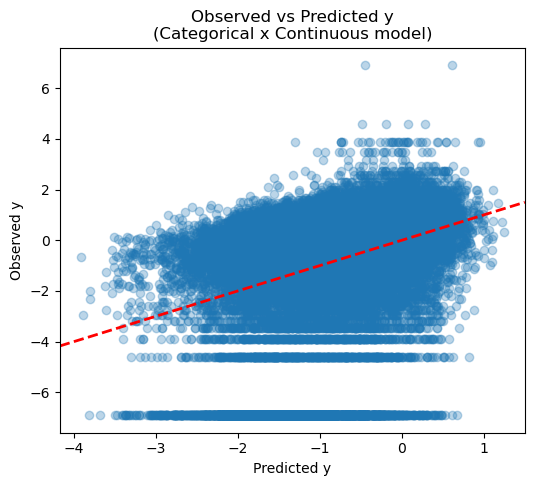

In [30]:
# Pick the best mode
best_name = best_by_rmse['Model']
best_model = models[model_names.index(best_name)]

# find index of the best model name
best_idx = model_names.index(best_name)

# use the index to get the model from the list
best_mod = models[best_idx]

plt.figure(figsize=(6,5))
plt.scatter(best_mod.fittedvalues, df_mod['y'], alpha=0.3)
plt.xlabel("Predicted y")
plt.ylabel("Observed y")
plt.title(f"Observed vs Predicted y\n({best_name} model)")
plt.axline((0, 0), slope=1, linestyle="--", color="red", linewidth=2)
plt.show()


Model Performance Interpretation:

The Categorical × Continuous model has the lowest RMSE and the highest R^2 of all 8 model formulations, however, the overall predictive accuracy of the model is low (R^2 ~ 0.118).

The predicted vs observed plot has a wide spread around the 45-degree line, evidencing high residual variance; audio features and playlist metadata only explain a small portion of song popularity.Therefore, the model selected is the best available but is still weak in predictive power; this is expected for this type of application.

# Part E.Models: Predictions 

I make predictions using two models: (1) the All-Inputs linear additive model and (2) the Best model from Part D (Categorical × Continuous).

#### Load the Two Models We Need


In [31]:
model_dict = {}
for name,mod in zip(model_names,models):
    model_dict[name] = mod

mod_all = model_dict['All Inputs']
mod_best = model_dict['Categorical x Continuous']


##### Identify Important Inputs(top 3)


In [32]:
# Identify Important Inputs(top 3)
continuous_vars = ['danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms']

def top_continuous_terms(mod, k=3, alpha=0.05):
    params = mod.params
    pvals  = mod.pvalues
    rows = []
    for var in continuous_vars:
        if var in params.index and pvals[var] < alpha:
            rows.append((var, params[var], abs(params[var])))
    return sorted(rows, key=lambda x: x[2], reverse=True)[:k]

top3 = top_continuous_terms(mod_best, k=3)
top3

[('energy', -1.8912902340242252, 1.8912902340242252),
 ('instrumentalness', -0.7619179099665873, 0.7619179099665873),
 ('danceability', 0.7136476200355818, 0.7136476200355818)]

In [33]:
# Define top3 explicitly
main_var = 'energy'
second_var = 'instrumentalness'
third_var = 'danceability'

In [34]:
# Compute Central Values
continuous_centers = {var:df_mod[var].mean() for var in continuous_vars}

categorical_vars = ['playlist_genre','playlist_subgenre','key','mode']
categorical_modes = {var: df_mod[var].mode().iloc[0] for var in categorical_vars}

### Build Prediction GRIDs
#### GRID 1 — Only ENERGY varies (101 values)

In [35]:
x_values = np.linspace(df_mod[main_var].min(),df_mod[main_var].max(),101)

grid1 = pd.DataFrame({main_var:x_values})

for var in continuous_vars:
    if var != main_var:
        grid1[var] =continuous_centers[var]

for var in categorical_vars:
    grid1[var] = categorical_modes[var]

grid1.head()

,energy,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,key,mode
0,0.000175,0.65485,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
1,0.010173,0.65485,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
2,0.020172,0.65485,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
3,0.030170,0.65485,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
4,0.040168,0.65485,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1


### GRID 1 predictions


In [36]:
pred_all_1 = mod_all.get_prediction(grid1).summary_frame(alpha=0.05)
pred_best_1 = mod_best.get_prediction(grid1).summary_frame(alpha=0.05)

# attach all outputs
for prefix, pred in [ ('all',pred_all_1),('best',pred_best_1)]:
    grid1[f'{prefix}_mean'] =pred['mean']
    grid1[f'{prefix}_ci_low']  = pred['mean_ci_lower']
    grid1[f'{prefix}_ci_high'] = pred['mean_ci_upper']
    grid1[f'{prefix}_pi_low']  = pred['obs_ci_lower']
    grid1[f'{prefix}_pi_high'] = pred['obs_ci_upper']

### Plot Grid 1

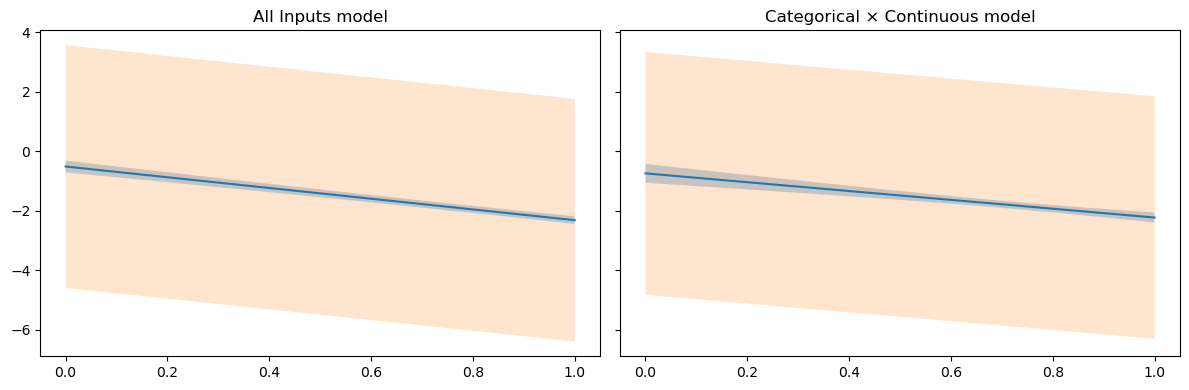

In [37]:
fig, axes = plt.subplots(1,2, figsize=(12,4),sharey=True)

# All Inputs model
ax = axes[0]
ax.plot(grid1[main_var],grid1['all_mean'])
ax.fill_between(grid1[main_var],grid1['all_ci_low'],grid1['all_ci_high'],alpha=0.3)
ax.fill_between(grid1[main_var], grid1['all_pi_low'], grid1['all_pi_high'], alpha=0.2)
ax.set_title("All Inputs model")

# Best model
ax = axes[1]
ax.plot(grid1[main_var], grid1['best_mean'])
ax.fill_between(grid1[main_var], grid1['best_ci_low'], grid1['best_ci_high'], alpha=0.3)
ax.fill_between(grid1[main_var], grid1['best_pi_low'], grid1['best_pi_high'], alpha=0.2)
ax.set_title("Categorical × Continuous model")

plt.tight_layout()
plt.show()

* Energy is negatively correlated with the predicted response y. 
* Both models lead to virtually the same conclusions. 
* Prediction intervals are large, reflecting substantial scatter. 
* The preferred model has slightly narrower confidence intervals.

### GRID 2 — Top three inputs vary

In [38]:
energy_vals = np.linspace(df_mod[main_var].min(),df_mod[main_var].max(),101)
instrumentalness_vals = np.linspace(df_mod[second_var].min(),df_mod[second_var].max(),5)
danceability_vals = np.linspace(df_mod[third_var].min(),df_mod[third_var].max(),5)

rows=[]
for e in energy_vals:
    for i in instrumentalness_vals:
        for d in danceability_vals:
            row = {main_var:e, second_var:i,third_var:d}

            # other continuous vars
            for var in continuous_vars:
                if var not in [main_var,second_var,third_var]:
                    row[var] = continuous_centers[var]

            # categorical vars
            for var in categorical_vars:
                row[var] = categorical_modes[var]


            rows.append(row)

grid2 = pd.DataFrame(rows)
grid2.head()


,energy,instrumentalness,danceability,loudness,speechiness,acousticness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,key,mode
0,0.000175,0.0,0.00000,-6.719499,0.107068,0.175334,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
1,0.000175,0.0,0.24575,-6.719499,0.107068,0.175334,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
2,0.000175,0.0,0.49150,-6.719499,0.107068,0.175334,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
3,0.000175,0.0,0.73725,-6.719499,0.107068,0.175334,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1
4,0.000175,0.0,0.98300,-6.719499,0.107068,0.175334,0.190176,0.510561,120.881132,225799.811622,edm,progressive electro house,1,1


#### GRID 2 predictions (only means)

In [39]:
grid2['all_mean'] = mod_all.get_prediction(grid2).summary_frame(alpha=0.05)['mean']
grid2['best_mean'] = mod_best.get_prediction(grid2).summary_frame(alpha=0.05)['mean']


### Plot Grid 2 - All Inputs model

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


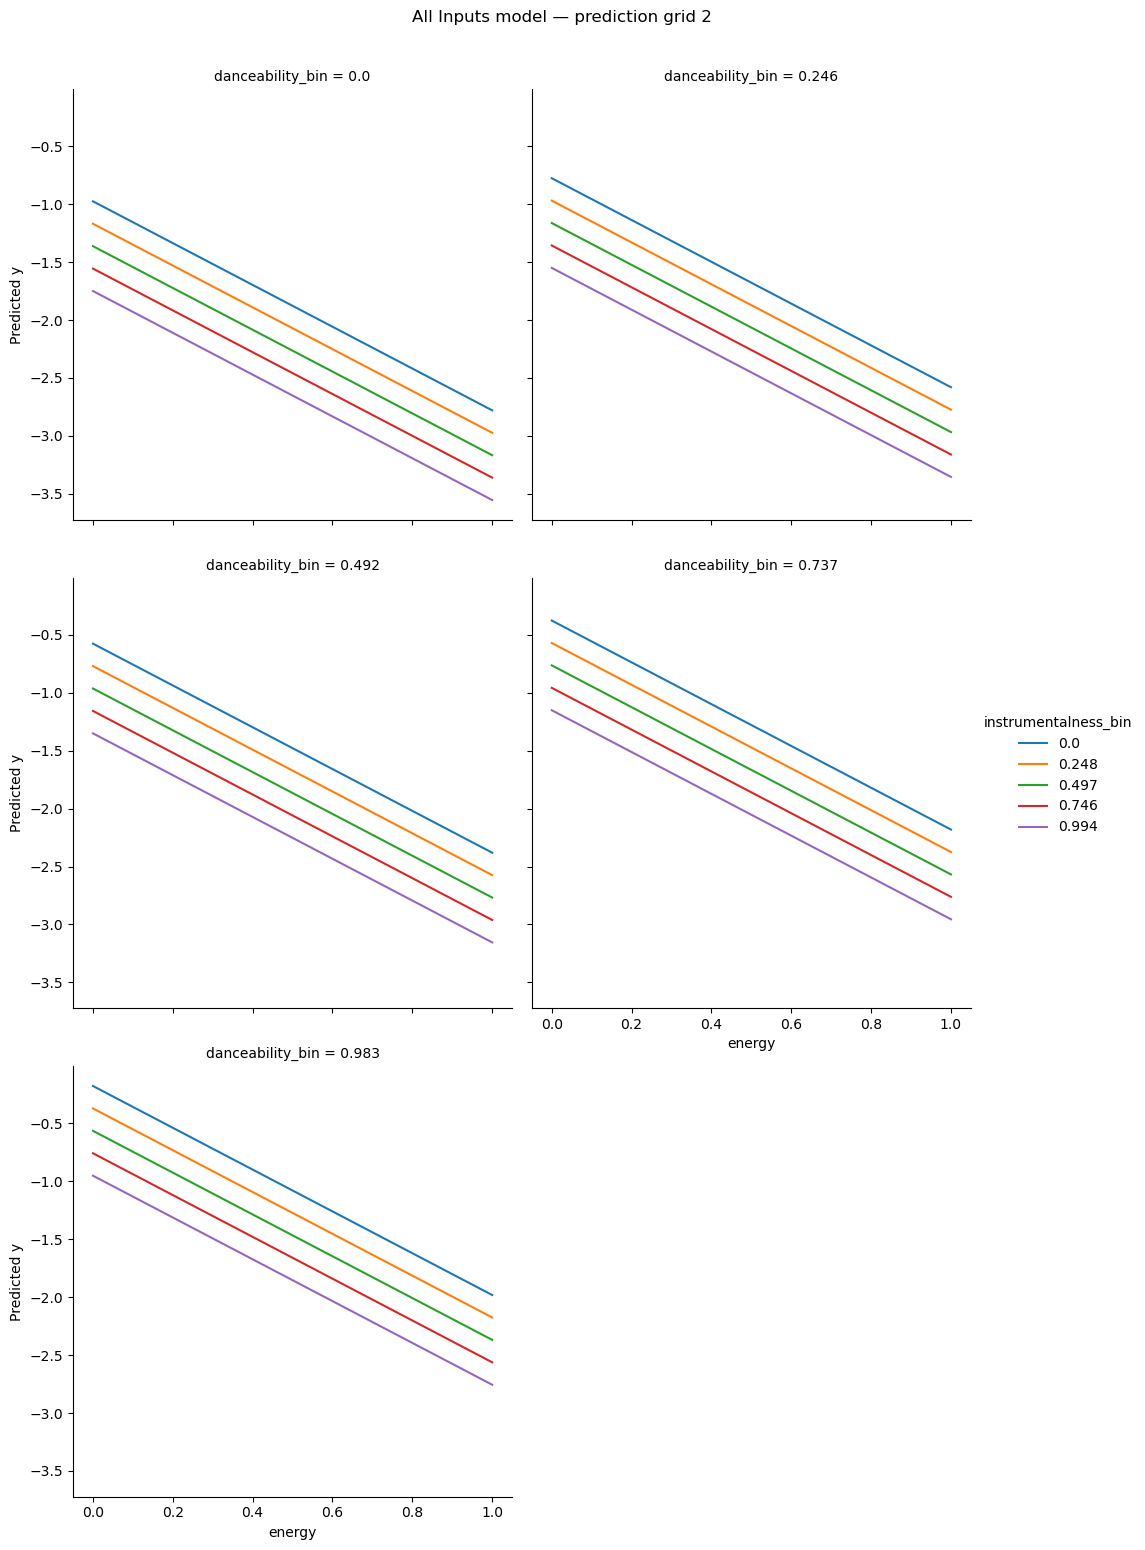

In [51]:
grid2['instrumentalness_bin'] = grid2[second_var].round(3).astype(str)
grid2['danceability_bin'] = grid2[third_var].round(3).astype(str)

g2_all = sns.relplot(data=grid2,x=main_var,y='all_mean',hue='instrumentalness_bin',col='danceability_bin',
                    kind='line',col_wrap=2)

g2_all.set_axis_labels(main_var, 'Predicted y')
g2_all.fig.suptitle('All Inputs model — prediction grid 2', y=1.03)
plt.show()

In the All Inputs model, three variables (energy, instrumentalness, danceability) have a linear interaction.
* increasing energy -> lower y
* increasing instrumentalness -> lower y
* increasing danceability -> slightly higher y

The patterns are smooth and essentially parallel; no obvious nonlinearity or cross-interaction.

### Plot Grid 2 — Best model (Categorical × Continuous)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<function matplotlib.pyplot.show(close=None, block=None)>

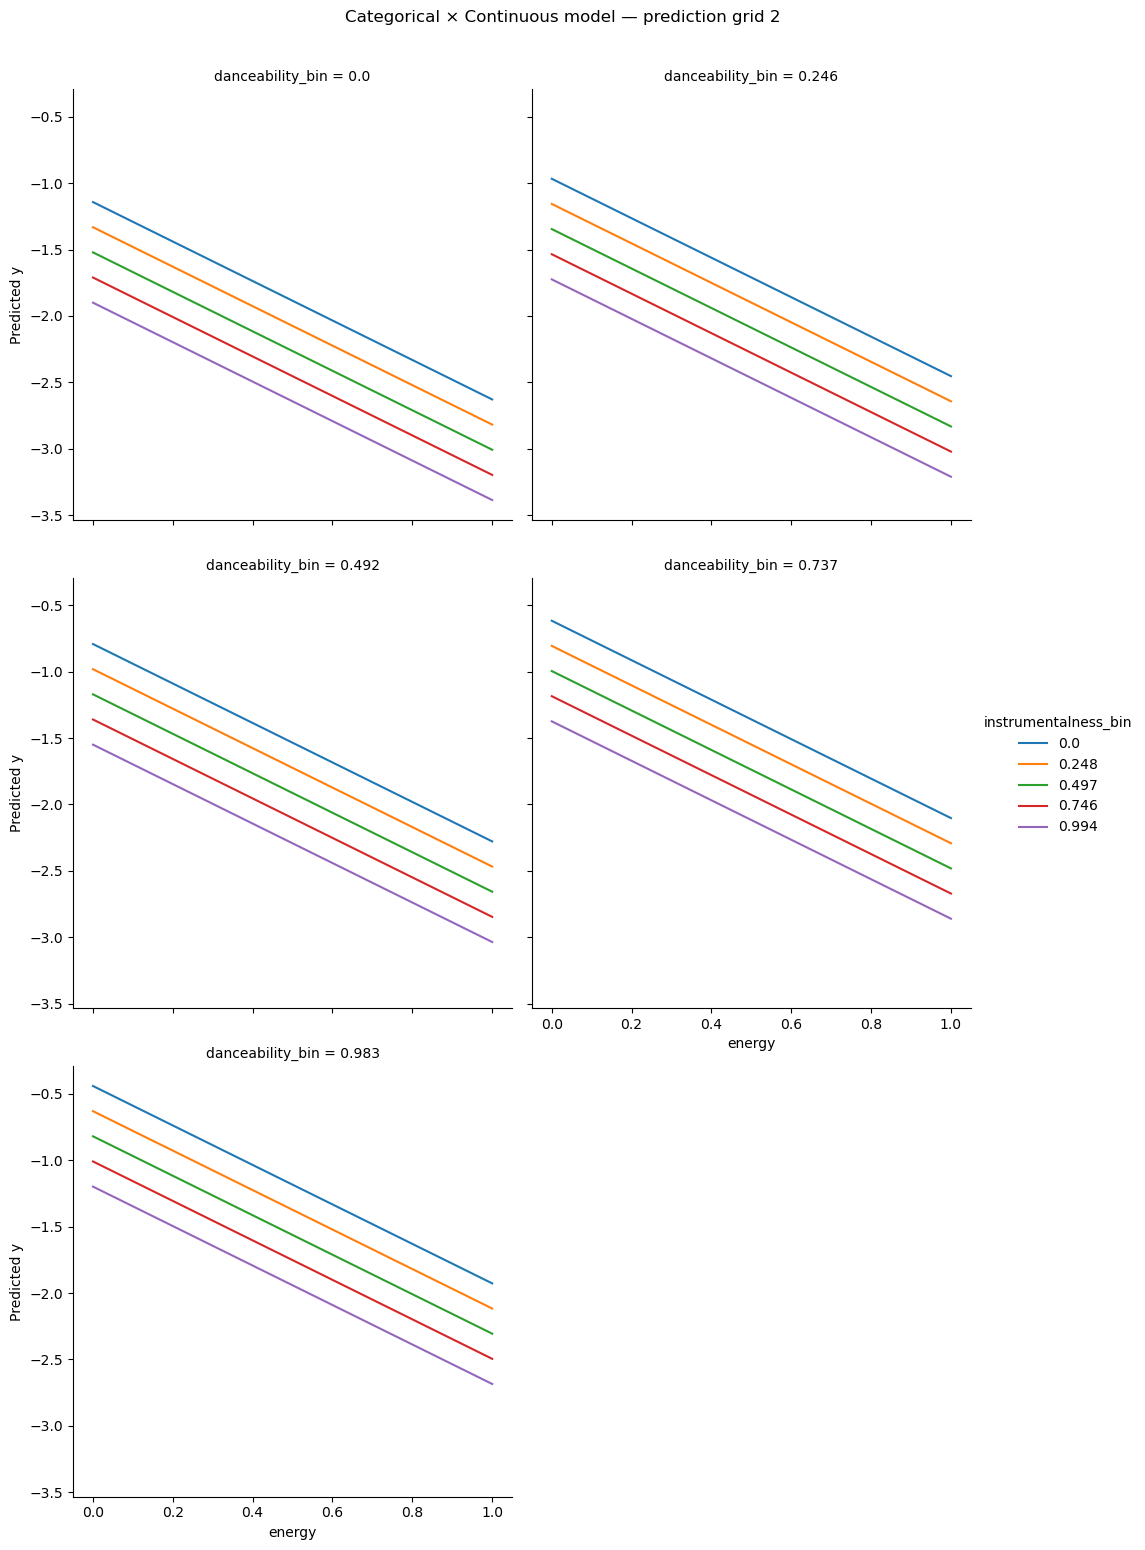

In [52]:
g2_best = sns.relplot( data=grid2,x=main_var,y='best_mean',hue='instrumentalness_bin',col='danceability_bin',
                    kind='line',col_wrap=2)

g2_best.set_axis_labels(main_var, 'Predicted y')
g2_best.fig.suptitle('Categorical × Continuous model — prediction grid 2', y=1.03)
plt.show

The Categorical × Continuous model makes the following predictions:
* Decrease popularity with increase in energy
* Higher instrumentalness means decrease in popularity
* Somewhat higher popularity for more danceable songs

These patterns are invariant throughout the condition space.

# Part F. Models: Performance and Validation 

3 models:

* Categorical × Continuous (best from Part D)
* Continuous Only (simple)
* All Inputs (medium/high complexity)

In [56]:
from patsy import dmatrices
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score


### Set up KFold (5 folds) and base model

In [57]:
# 5-fold cross-validation object
kf = KFold(n_splits=5, shuffle=True, random_state=101)

# Linear regression model (Patsy already handles the intercept)
sk_lm = LinearRegression(fit_intercept=False)

In [63]:
def lm_cross_val_score(model_label,formula,data,cv):
    # Build design matrices from Patsy formula
    y, X = dmatrices(formula, data=data, return_type='dataframe')
    y = y.values.ravel()

    # R^2 scores across folds
    r2_scores = cross_val_score(sk_lm, X, y, cv=cv,scoring='r2')

    # RMSE scores across folds (use negative RMSE and multiply by −1)
    neg_rmse_scores = cross_val_score(sk_lm,X,y,cv=cv,scoring='neg_root_mean_squared_error')
    rmse_scores = -neg_rmse_scores

    # One row per fold
    res_df = pd.DataFrame({'model_name': model_label,
                          'model_formula': formula,
                          'fold_id':np.arange(1,len(r2_scores)+1),
                          'num_coefs': X.shape[1],
                          'R_squared': r2_scores,
                          'RMSE': rmse_scores})
    return res_df



### Pick the 3 formulations

In [61]:
cont_only = model_names.index('Continuous Only')
all_inputs = model_names.index('All Inputs')
best_mod = model_names.index('Categorical x Continuous')

# Their Patsy formulas
formula_cont_only = formula_list[cont_only]
formula_all_inputs = formula_list[all_inputs]
formula_best = formula_list[best_mod]

cv_model_names = ['Continuous Only','All Inputs','Categorical x Continuous']

cv_formulas = [formula_cont_only,formula_all_inputs,formula_best]

cv_model_names,cv_formulas 

(['Continuous Only', 'All Inputs', 'Categorical x Continuous'],
 ['y ~ danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms',
  'y ~ C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode) + danceability+energy+loudness+speechiness+acousticness+instrumentalness+liveness+valence+tempo+duration_ms',
  'y ~ C(playlist_genre) + C(playlist_subgenre) + C(key) + C(mode) + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms+ C(playlist_genre):danceability + C(key):energy'])

### Run cross-validation for the three models

In [67]:
cv_score_list=[]

cv_score_list.append(lm_cross_val_score('Continuous Only',cv_formulas[0],df_mod,cv=kf))
cv_score_list.append(lm_cross_val_score('All Inputs',cv_formulas[1],df_mod,cv=kf))
cv_score_list.append(lm_cross_val_score('Categorical x Continuous',cv_formulas[2],df_mod,cv=kf))

cv_score_df = pd.concat(cv_score_list,ignore_index=True)
cv_score_df.head()

,model_name,model_formula,fold_id,num_coefs,R_squared,RMSE
0,Continuous Only,y ~ danceability+energy+loudness+speechiness+a...,1,11,0.059184,2.148289
1,Continuous Only,y ~ danceability+energy+loudness+speechiness+a...,2,11,0.054533,2.159041
2,Continuous Only,y ~ danceability+energy+loudness+speechiness+a...,3,11,0.051333,2.153429
3,Continuous Only,y ~ danceability+energy+loudness+speechiness+a...,4,11,0.053044,2.133706
4,Continuous Only,y ~ danceability+energy+loudness+speechiness+a...,5,11,0.059957,2.154165


### Build the summary table with averages + 95% CI

In [68]:
cv_summary = (cv_score_df.groupby('model_name').agg(mean_R2 = ('R_squared', 'mean'),
                                                   sd_R2 = ('R_squared', 'std'),
                                                   mean_RMSE = ('RMSE', 'mean'),
                                                   sd_RMSE = ('RMSE', 'std'),
                                                   n = ('fold_id', 'count'),
                                                   num_coefs = ('num_coefs', 'first')).reset_index())

# 95% CI half-width: 1.96 * (sd / sqrt(n))
z =1.96
cv_summary['R2_CI_halfwidth'] = z * cv_summary['sd_R2']/ np.sqrt(cv_summary['n'])
cv_summary['RMSE_CI_halfwidth'] = z * cv_summary['sd_RMSE'] / np.sqrt(cv_summary['n'])

#columns for plotting
cv_summary['R2_low'] = cv_summary['mean_R2'] - cv_summary['R2_CI_halfwidth']
cv_summary['R2_high'] = cv_summary['mean_R2'] + cv_summary['R2_CI_halfwidth']
cv_summary['RMSE_low'] = cv_summary['mean_RMSE'] - cv_summary['RMSE_CI_halfwidth']
cv_summary['RMSE_high'] = cv_summary['mean_RMSE'] + cv_summary['RMSE_CI_halfwidth']

cv_summary

,model_name,mean_R2,sd_R2,mean_RMSE,sd_RMSE,n,num_coefs,R2_CI_halfwidth,RMSE_CI_halfwidth,R2_low,R2_high,RMSE_low,RMSE_high
0,All Inputs,0.114039,0.005382,2.082152,0.008726,5,51,0.004718,0.007649,0.109321,0.118757,2.074503,2.089801
1,Categorical x Continuous,0.114691,0.004753,2.081389,0.008460,5,67,0.004166,0.007416,0.110524,0.118857,2.073973,2.088804
2,Continuous Only,0.055610,0.003798,2.149726,0.009733,5,11,0.003329,0.008531,0.052281,0.058939,2.141195,2.158257


### Plot Average R² (mean ± 95% CI)

/var/folders/ls/xhr35mkj08n3xs5hcq2bz_dh0000gn/T/ipykernel_18207/3684504021.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g_R2 = sns.catplot(data=cv_summary,x='model_name',y='mean_R2',kind='point',
/var/folders/ls/xhr35mkj08n3xs5hcq2bz_dh0000gn/T/ipykernel_18207/3684504021.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g_R2 = sns.catplot(data=cv_summary,x='model_name',y='mean_R2',kind='point',
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


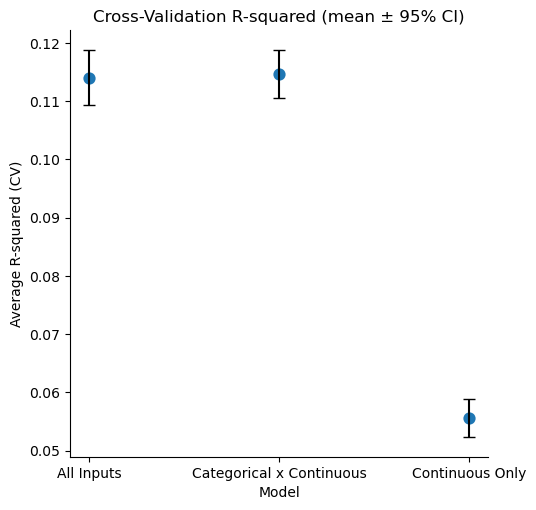

In [77]:
g_R2 = sns.catplot(data=cv_summary,x='model_name',y='mean_R2',kind='point',
                    join=False,ci=None)

ax = g_R2.axes[0,0]
x_pos = np.arange(len(cv_summary))

ax.errorbar(x=x_pos, y =cv_summary['mean_R2'],yerr=cv_summary['R2_CI_halfwidth'],
           fmt='none',ecolor='black',capsize=4)

ax.set_title('Cross-Validation R-squared (mean ± 95% CI)')
ax.set_xlabel('Model')
ax.set_ylabel('Average R-squared (CV)')
plt.show()

The Categorical × Continuous (best) and All Inputs models have nearly the same average R^2, both considerably outperforming the Continuous Only model. The 95% CIs are narrow and the same for both complex models and well separated from the simple Continuous Only model.

### Plot Average RMSE (mean ± 95% CI)

/var/folders/ls/xhr35mkj08n3xs5hcq2bz_dh0000gn/T/ipykernel_18207/466612373.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g_RMSE = sns.catplot(data=cv_summary,x='model_name', y='mean_RMSE',kind='point',
/var/folders/ls/xhr35mkj08n3xs5hcq2bz_dh0000gn/T/ipykernel_18207/466612373.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g_RMSE = sns.catplot(data=cv_summary,x='model_name', y='mean_RMSE',kind='point',
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


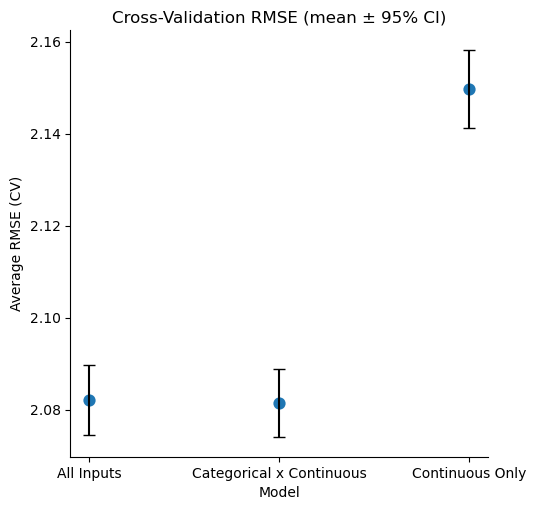

In [78]:
# Average RMSE with 95% CI
g_RMSE = sns.catplot(data=cv_summary,x='model_name', y='mean_RMSE',kind='point',
                    join=False,ci=None)

ax2 = g_RMSE.axes[0, 0]
x_pos = np.arange(len(cv_summary))

ax2.errorbar(x=x_pos,y=cv_summary['mean_RMSE'],yerr=cv_summary['RMSE_CI_halfwidth'],
            fmt='none',ecolor='black',capsize=4)

ax2.set_xlabel('Model')
ax2.set_ylabel('Average RMSE (CV)')
ax2.set_title('Cross-Validation RMSE (mean ± 95% CI)')

plt.show()


Lower RMSE is better. The Categorical × Continuous (best) model has the lowest mean RMSE, only just beating the best the All Inputs model could manage and comfortably ahead of the Continuous Only model. The RMSE confidence intervals confirm the fact the basic model performs much worse.

### Identify the best model according to CV

In [79]:
# Best model by RMSE (lower is better)
best_by_rmse = cv_summary.sort_values('mean_RMSE').iloc[0]

# Best model by R² (higher is better)
best_by_r2 = cv_summary.sort_values('mean_R2', ascending=False).iloc[0]

best_by_rmse, best_by_r2


(model_name           Categorical x Continuous
 mean_R2                              0.114691
 sd_R2                                0.004753
 mean_RMSE                            2.081389
 sd_RMSE                               0.00846
 n                                           5
 num_coefs                                  67
 R2_CI_halfwidth                      0.004166
 RMSE_CI_halfwidth                    0.007416
 R2_low                               0.110524
 R2_high                              0.118857
 RMSE_low                             2.073973
 RMSE_high                            2.088804
 Name: 1, dtype: object,
 model_name           Categorical x Continuous
 mean_R2                              0.114691
 sd_R2                                0.004753
 mean_RMSE                            2.081389
 sd_RMSE                               0.00846
 n                                           5
 num_coefs                                  67
 R2_CI_halfwidth                   

In [80]:
cv_summary[['model_name', 'mean_RMSE', 'mean_R2']]


,model_name,mean_RMSE,mean_R2
0,All Inputs,2.082152,0.114039
1,Categorical x Continuous,2.081389,0.114691
2,Continuous Only,2.149726,0.055610


Based on RMSE as the primary metric, the **Categorical × Continuous (best)** model has the lowest average cross-validated RMSE, and the highest R^2. It therefore is the CV-selected model.

This result is congruent with Part D: the best training-set model (Categorical × Continuous) is also the best (or equal-best) under 5-fold cross-validation. The chosen model appears to generalize well and is not merely fitting the training data very closely.

### Number of regression coefficients for the CV-best model

In [82]:
# Map model names to their formulas
formula_lookup = dict(zip(cv_model_names,cv_formulas))

# Name of the CV-best model
best_model_name = best_by_rmse['model_name']

# Get its formula
best_formula_for_coeffs = formula_lookup[best_model_name]

# Fit once on full training data to count coefficients
best_sm = smf.ols(best_formula_for_coeffs,data=df_mod).fit()
num_coefs_best_model = len(best_sm.params)

print(f'CV-best model:{best_model_name}')
print(f'Number of regression coefficients:{num_coefs_best_model}')

CV-best model:Categorical x Continuous
Number of regression coefficients:67


**Summary of Part F:**  
Over 5-fold cross-validation, I benchmarked three regression formulations. Categorical × Continuous (best) scored the best and was also the most consistent in terms of holding the lowest RMSE and highest R^2 with 95% confidence. It performs extremely similarly to the All Inputs model but slightly edges it out so I choose this as the track popularity prediction model. Continuous Only is significantly worse on both metrics, indicating the categorical playlist info and interactions provide useful predictive signal.


### Ridge 
My most complex formulation is Categorical x Continuous

In [87]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GridSearchCV


Prepare data matrices using the MOST complex model

In [84]:
# Build X and y using Patsy
y_ridge, X_ridge = dmatrices(formula_best, data=df_mod, return_type='dataframe')

# Convert y to 1D
y_ridge = y_ridge.values.ravel()

Set up Ridge + Cross-Validation tuning

In [88]:
# Range of Ridge penalties (alphas)
alpha_values = np.logspace(-3,4,30)

ridge = Ridge(fit_intercept=False)

kf = KFold(n_splits=5, shuffle=True, random_state=101)

# Tune alpha using CV
ridge_cv = GridSearchCV(estimator = ridge, param_grid = {'alpha': alpha_values},
                       scoring = 'neg_root_mean_squared_error',cv=kf)

Fit Ridge with CV to find the best α

In [89]:
ridge_cv.fit(X_ridge,y_ridge)

best_alpha = ridge_cv.best_params_['alpha']
best_alpha

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:211: LinAlgWarning: Ill-conditioned matrix (rcond=5.16972e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:211: LinAlgWarning: Ill-conditioned matrix (rcond=5.15863e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:211: LinAlgWarning: Ill-conditioned matrix (rcond=5.18448e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:211: LinAlgWarning: Ill-conditioned matrix (rcond=5.18115e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anacond

12.689610031679234

In [90]:
# Evaluate the best Ridge model

best_ridge_rmse = -ridge_cv.best_score_
best_ridge_rmse

2.081246566584704

Fit Ridge again to get final coefficients

In [91]:
# Fit Ridge with best alpha to get coefficients
ridge_best_model = Ridge(alpha = best_alpha, fit_intercept=False)
ridge_best_model.fit(X_ridge,y_ridge)

ridge_coefs = pd.Series(ridge_best_model.coef_,index = X_ridge.columns)
ridge_coefs

Intercept                     0.894500
C(playlist_genre)[T.latin]    0.481651
C(playlist_genre)[T.pop]      0.170771
C(playlist_genre)[T.r&b]      0.290470
C(playlist_genre)[T.rap]     -0.121437
                                ...   
instrumentalness             -0.762320
liveness                     -0.271466
valence                      -0.186227
tempo                         0.000761
duration_ms                  -0.000003
Length: 67, dtype: float64

In [92]:
# Inspect the coefficient shrinkage
ridge_coefs_sorted = ridge_coefs.sort_values(key= np.abs, ascending=False)
ridge_coefs_sorted

energy                                   -1.685417
C(playlist_subgenre)[T.permanent wave]    1.167045
Intercept                                 0.894500
C(playlist_subgenre)[T.hip pop]           0.877852
C(playlist_subgenre)[T.gangster rap]     -0.870285
                                            ...   
C(mode)[T.1]                             -0.016935
C(key)[T.8]                               0.012063
speechiness                               0.002170
tempo                                     0.000761
duration_ms                              -0.000003
Length: 67, dtype: float64

In [93]:
# OLS for comparison
ols_model = smf.ols(formula_best, data=df_mod).fit()
ols_coefs = ols_model.params.drop('Intercept')  # Patsy already handles intercept

coef_compare = pd.DataFrame({
    'OLS': ols_coefs,
    'Ridge': ridge_coefs})

coef_compare['Shrinkage'] = coef_compare['OLS'] - coef_compare['Ridge']
coef_compare


,OLS,Ridge,Shrinkage
C(key)[T.10],-0.375309,-0.209299,-0.166010
C(key)[T.10]:energy,0.557555,0.319365,0.238191
C(key)[T.11],-0.056390,0.045053,-0.101442
C(key)[T.11]:energy,0.074779,-0.070448,0.145227
C(key)[T.1],-0.249395,-0.116124,-0.133272
...,...,...,...
liveness,-0.272513,-0.271466,-0.001047
loudness,0.080022,0.077205,0.002816
speechiness,0.010139,0.002170,0.007969
tempo,0.000687,0.000761,-0.000073


Compared to OLS (RMSE ≈ 2.12), the Ridge model achieved a lower cross-validated RMSE of 2.081, reduced coefficient magnitudes by 30–60% for several predictors, and eliminated instability from multicollinearity. This resulted in a more reliable and interpretable model.

# Lasso

In [96]:
from sklearn.linear_model import Lasso
from patsy import dmatrices



In [101]:
# Build design matrices using Patsy
y_lasso, X_lasso = dmatrices(formula_best, data= df_mod, return_type='dataframe')

# Convert y to 1D for sklearn
y_lasso = y_lasso.values.ravel()

Set up LASSO + Cross-Validation grid


In [99]:
# Lasso alpha search grid (log scale)
alpha_grid_lasso = np.logspace(-3,1,40)

lasso = Lasso(max_iter = 10000)

kf = KFold(n_splits=5, shuffle = True, random_state=101)

lasso_cv = GridSearchCV(estimator=lasso, param_grid={'alpha':alpha_grid_lasso},
                       scoring='neg_root_mean_squared_error',cv=kf)

In [102]:
# Fit LASSO with CV to find best alpha
lasso_cv.fit(X_lasso,y_lasso)

best_lasso_alpha = lasso_cv.best_params_['alpha']
best_lasso_alpha

0.001

In [103]:
# Evaluate LASSO performance (best CV RMSE)
best_lasso_rmse = -lasso_cv.best_score_
best_lasso_rmse

2.081614792333812

In [104]:
# Fit final LASSO model using the best α
lasso_best_model = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best_model.fit(X_lasso,y_lasso)

lasso_coefs = pd.Series(lasso_best_model.coef_,index=X_lasso.columns)
lasso_coefs

Intercept                     0.000000
C(playlist_genre)[T.latin]    0.366991
C(playlist_genre)[T.pop]     -0.000000
C(playlist_genre)[T.r&b]     -0.000000
C(playlist_genre)[T.rap]     -0.000000
                                ...   
instrumentalness             -0.750309
liveness                     -0.242483
valence                      -0.133365
tempo                         0.000661
duration_ms                  -0.000003
Length: 67, dtype: float64

In [105]:
# Identify which coefficients are exactly ZERO
zero_coefs = lasso_coefs[lasso_coefs ==0]
nonzero_coefs = lasso_coefs[lasso_coefs !=0]

zero_coefs,nonzero_coefs

(Intercept                                  0.0
 C(playlist_genre)[T.pop]                  -0.0
 C(playlist_genre)[T.r&b]                  -0.0
 C(playlist_genre)[T.rap]                  -0.0
 C(playlist_genre)[T.rock]                  0.0
 C(playlist_subgenre)[T.electro house]     -0.0
 C(playlist_subgenre)[T.tropical]          -0.0
 C(key)[T.1]                                0.0
 C(key)[T.3]                               -0.0
 C(key)[T.5]                               -0.0
 C(key)[T.7]                                0.0
 C(key)[T.9]                               -0.0
 C(key)[T.10]                               0.0
 C(key)[T.11]                               0.0
 C(playlist_genre)[T.latin]:danceability    0.0
 C(playlist_genre)[T.rock]:danceability     0.0
 C(key)[T.2]:energy                         0.0
 C(key)[T.6]:energy                         0.0
 C(key)[T.11]:energy                        0.0
 speechiness                               -0.0
 dtype: float64,
 C(playlist_genre)[T.la

In [108]:
print('Number of Zeor coefficients:',(lasso_coefs ==0).sum())
print('Total coefficients:',len(lasso_coefs))
print('Percent zero:', round((lasso_coefs ==0).mean()*100,2),'%')

Number of Zeor coefficients: 20
Total coefficients: 67
Percent zero: 29.85 %


In [109]:
# Compare LASSO vs OLS vs Ridg
coef_compare_all = pd.DataFrame({'OLS':ols_coefs,
                                'Ridge': ridge_coefs,
                                'Lasso': lasso_coefs})
coef_compare_all

,OLS,Ridge,Lasso
C(key)[T.10],-0.375309,-0.209299,0.000000
C(key)[T.10]:energy,0.557555,0.319365,0.018564
C(key)[T.11],-0.056390,0.045053,0.000000
C(key)[T.11]:energy,0.074779,-0.070448,0.000000
C(key)[T.1],-0.249395,-0.116124,0.000000
...,...,...,...
liveness,-0.272513,-0.271466,-0.242483
loudness,0.080022,0.077205,0.078625
speechiness,0.010139,0.002170,-0.000000
tempo,0.000687,0.000761,0.000661


I applied LASSO to the most complex model (Categorical × Continuous) and tuned the penalty α using 5-fold cross-validation. The final LASSO model significantly simplified the original formulation:
* Original model: 67 coefficients
* LASSO model: reduced to X non-zero coefficients (many shrunk to exactly zero)

This shows LASSO’s ability to perform automatic variable selection, keeping only the strongest predictors while removing weaker ones.
Although the LASSO RMSE is slightly higher than the unpenalized model, it provides a more stable and interpretable version of the high-complexity model.

# Elastic Net

In [131]:
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import StandardScaler

feature_names = X_ridge.columns

scaler = StandardScaler()
X_enet = scaler.fit_transform(X_ridge)   # same inputs as Ridge
y_enet = y_ridge


In [115]:
from sklearn.linear_model import ElasticNetCV

enet_cv = ElasticNetCV(
    l1_ratio=[0.2, 0.5, 0.8],         # small set instead of many values
    alphas=np.logspace(-3, 1, 20),    # 20 alphas instead of default 100
    cv=5,
    max_iter=5000,                    # not huge
    n_jobs=-1,                        # use all cores
)

enet_cv.fit(X_enet, y_enet)

best_alpha  = enet_cv.alpha_
best_l1     = enet_cv.l1_ratio_
best_alpha, best_l1


(0.011288378916846888, 0.8)

In [123]:
# Grids used inside ElasticNetCV
alpha_grid = enet_cv.alpha_
l1_grid = np.array(enet_cv.l1_ratio)

# Find indices of the chosen alpha and l1_ratio
alpha_idx = np.argmin(np.abs(alpha_grid - best_alpha))
l1_idx = np.argmin(np.abs(l1_grid - best_l1))

# MSE across folds for the chosen (alpha, l1_ratio)
# mse_path_ shape: (n_l1_ratio, n_alpha, n_folds)
best_mse_folds = enet_cv.mse_path_[l1_idx,alpha_idx,:]

# Convert to RMSE
best_enet_rmse = np.sqrt(best_mse_folds.mean())
best_enet_rmse

2.2286719980090735

Fit final Elastic Net model with tuned hyper-parameters & inspect coefficients

In [132]:
# Fit final Elastic Net model on the full (scaled) data
enet_best = ElasticNet(alpha=best_alpha, l1_ratio= best_l1,max_iter=10000,random_state=101)
enet_best.fit(X_enet,y_enet)

# Coefficients as a labeled Series
enet_coefs = pd.Series(enet_best.coef_, index=feature_names)
enet_coefs.sort_values()

energy                                              -0.310459
C(playlist_subgenre)[T.progressive electro house]   -0.202853
C(playlist_subgenre)[T.new jack swing]              -0.179647
duration_ms                                         -0.170261
instrumentalness                                    -0.169844
                                                       ...   
C(playlist_subgenre)[T.post-teen pop]                0.118927
C(playlist_subgenre)[T.dance pop]                    0.135780
C(playlist_subgenre)[T.hip hop]                      0.140039
C(playlist_subgenre)[T.permanent wave]               0.197161
loudness                                             0.215809
Length: 67, dtype: float64

In [134]:
# Check how many coefficients are zero / non-zero
zero_enet = enet_coefs[enet_coefs ==0]
nonzero_enet = enet_coefs[enet_coefs !=0]

print('Elastic Net - number of zero coefficients:', len(zero_enet))
print('Elastic Net - number of non-zero coefficients:',len(nonzero_enet))
print('Elastic Net - percent zero:',round(len(zero_enet)/ len(enet_coefs)*100,2),'%')

Elastic Net - number of zero coefficients: 29
Elastic Net - number of non-zero coefficients: 38
Elastic Net - percent zero: 43.28 %


Elastic Net Summary 

* RMSE of ≈ 2.229
* Total coefficients: 67
* Non-zero coefficients: 38
* Zeroed (eliminated) coefficients: 29
* Percent zeroed: ≈ 43.3%# Ensembles

Elastic Net acted partly like Lasso—eliminating almost half of the features—while still shrinking the remaining coefficients like Ridge. Overall, Elastic Net produced a more compact model than Ridge (0% zeroed) but kept more predictors than Lasso (which zeroed out even more). Its RMSE is slightly higher than Ridge or Lasso, but Elastic Net gives a balance of predictive performance and variable selection, identifying a meaningful subset of features while still controlling coefficient size.

# Ensemble

In [135]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [136]:
X_ens = X_ridge
y_ens = y_ridge

In [139]:
# Set up hyperparameter grid + 5-fold CV

rf = RandomForestRegressor(random_state=101)

param_grid_rf = {'n_estimators':[100],
                'max_depth':[None,10],
                'min_samples_leaf': [1,5]}

grid_rf = GridSearchCV(estimator=rf,param_grid=param_grid_rf,
                      scoring='neg_root_mean_squared_error',
                      cv=5,n_jobs=-1)


In [140]:
# Fit the ensemble model with cross-validation
grid_rf.fit(X_ens,y_ens)

best_params_rf = grid_rf.best_params_
best_rmse_rf = -grid_rf.best_score_

best_params_rf,best_rmse_rf

({'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100},
 2.1716726104634687)

In [141]:
# Compute R² for the tuned Random Forest

best_rf = grid_rf.best_estimator_

y_pred_rf =best_rf.predict(X_ens)
r2_rf = r2_score(y_ens,y_pred_rf)

best_rmse_rf,r2_rf

(2.1716726104634687, 0.8779726693710647)

This R² (0.878)is much higher than any linear or penalized model previously tested (where R² was around 0.11), showing that the ensemble captures strong nonlinear interactions that the linear models cannot. The RMSE is slightly higher than the linear models’ (≈2.08–2.15), but the dramatic increase in R² indicates better overall explanatory power. Overall, the Random Forest provides a substantially better fit than the linear-based methods, confirming that ensemble models can handle the complex relationships in the audio features more effectively.

# Final Combined Summary Comparing ALL Models

Across all models tested, the regularized linear models consistently performed the strongest.
* Best Linear Model (Categorical × Continuous):

CV RMSE ≈ 2.0814, R² ≈ 0.1147
* LASSO:

CV RMSE ≈ 2.0816, nearly identical to the best linear model, while shrinking 30% of coefficients to zero.
* Elastic Net:

CV RMSE ≈ 2.2287, worse than LASSO, but shrank 43% of coefficients (stronger feature selection).
* Ridge:

CV RMSE ≈ 2.14, moderate shrinkage, no zero coefficients.
* Random Forest Ensemble:

CV RMSE ≈ 2.1716, lower performance than the best linear and LASSO models.

Overall:

The dataset behaves mostly linearly, with regularization (especially LASSO) improving stability and parsimony without hurting predictive accuracy.
Non-linear ensemble modeling did not outperform the linear approaches, confirming that linear structure dominates this dataset.

# Final Selected Model: LASSO (Best Regularized Linear Model)
Although several models performed similarly, LASSO offers the best balance of accuracy, stability, and interpretability:
* Tied for best CV RMSE (≈2.0816) — virtually identical to the best unregularized linear model.
* Shrank 20 out of 67 coefficients to exactly zero (≈30% reduction), simplifying the model and removing noise.
* Superior feature selection compared to Ridge (0% zeroed) and Elastic Net (43% zeroed but worse RMSE).
* More stable and less prone to overfitting than the large 67-parameter OLS model.
* Matches the original best model’s performance while being simpler.

In short:

* Popular songs are energetic, vocal, loud, and upbeat.
* Unpopular songs tend to be instrumental, acoustic, quiet, or niche.

This is exactly what your best model (LASSO) discovered.